# **Práctica 2: Clasificación de Géneros Musicales usando Redes Neuronales**

## **Nombre del Estudiante:** Javier Díaz-Cano Rincón

## **Fecha:** 28/11/2025
-----

---

## Descripción de la Práctica

Durante esta asignatura habéis visto la cantidad de opciones que se abren a la hora de abordar un problema de predicción mediante redes neuronales. Esas opciones impactan directamente sobre los resultados obtenidos. Además, durante el entrenamiento de nuestras redes neuronales pueden surgir diferentes problemas. Es hora de que os enfrentéis en solitario a un problema real de clasificación utilizando redes neuronales, aplicando los conceptos aprendidos en clase.

En esta práctica, construiréis y entrenaréis una red neuronal para clasificar géneros musicales basándoos en diversas características de audio. Utilizaréis un conjunto de datos real que contiene múltiples características relevantes.

##  Enunciado del Problema

Trabajas como ingeniero/a de IA para una plataforma de *streaming* de música (piensa en Spotify, Apple Music). El equipo de contenido necesita un sistema automatizado para clasificar canciones en géneros basándose en sus características de audio. Esto ayuda a:

  - Generación automática de *playlists*.
  - Mejorar los sistemas de recomendación.
  - Organización y descubrimiento de contenido.
  - Selección de música basada en el estado de ánimo (*mood*).

Construir un clasificador de red neuronal que prediga el **género musical** basándose en las características de audio extraídas de clips de 30 segundos de canciones. El modelo debe clasificar las canciones en uno de 10 géneros.

-----

## 📊 Descripción del Dataset

**Dataset:** GTZAN Dataset - Music Genre Classification  
**Alternativa:** FMA (Free Music Archive) Small dataset  
**Fuente:** [https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification](https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification)  
**Tamaño:** 1.000 pistas de audio (100 por género) × 30 segundos cada una.  
**Features:** 57 características (features) de audio extraídas usando la librería Librosa.

### Géneros (10 Clases)

| ID Género | Nombre Género | Características | Ejemplos |
|-----------|---------------|-----------------|----------|
| 0 | Blues | Tempo lento, emocional, centrado en guitarra | B.B. King, Muddy Waters |
| 1 | Clásica | Orquestal, armonía compleja | Mozart, Bach, Beethoven |
| 2 | Country | Narrativo, acústico, *twang* | Johnny Cash, Dolly Parton |
| 3 | Disco | Bailable, ritmo 4/4, sintetizadores | Bee Gees, Donna Summer |
| 4 | Hip-Hop | Habla rítmica, *beats*, *sampling* | Tupac, Notorious B.I.G. |
| 5 | Jazz | Improvisación, *swing*, viento-metal | Miles Davis, John Coltrane |
| 6 | Metal | Guitarra pesada, agresivo, rápido | Metallica, Iron Maiden |
| 7 | Pop | Pegadizo, *mainstream*, variado | Madonna, Michael Jackson |
| 8 | Reggae | Ritmo *offbeat*, relajado | Bob Marley, Peter Tosh |
| 9 | Rock | Centrado en guitarra, enérgico | The Beatles, Led Zeppelin |

### *Features* de Audio (57 total)

Las *features* se extraen de cada clip de 30 segundos y se agregan (media, varianza, etc.):

| Categoría | *Features* | Descripción | Cantidad |
|-----------------|----------|-------------|-------|
| **Espectrales** | Chroma (12), Centroide Espectral (2), Ancho de Banda Espectral (2), *Spectral Rolloff* (2) | Características del dominio de la frecuencia | 18 |
| **Rítmicas** | Tempo (1), *Zero Crossing Rate* (2) | Características temporales | 3 |
| **Tímbricas** | MFCCs (26), Contraste Espectral (14) | Color tonal y textura | 40 |
| **Metadatos** | Duración (1) | Duración de la pista | 1 |

**Detalles de las *Features*:**

  - **Chroma Features (12):** Distribución de energía entre las 12 clases de tono (C, C\#, D, etc.)
  - **MFCCs (26):** Coeficientes Cepstrales Mel-Frequency - representan el timbre (13 coeficientes × media/varianza)
  - **Centroide Espectral:** "Centro de masa" del espectro.
  - **Ancho de Banda Espectral:** Anchura del espectro.
  - **Spectral Rolloff:** Frecuencia por debajo de la cual se concentra el 85% de la energía.
  - **Zero Crossing Rate:** Frecuencia con la que la señal cambia de signo (relacionado con el ruido).
  - **Tempo:** *Beats* por minuto (BPM).
  - **Contraste Espectral:** Diferencia entre picos y valles en el espectro.

**Variable Objetivo:** `genre` - Uno de 10 géneros (0-9)

-----

## Rúbrica de Evaluación (100 puntos total)

| Componente | Puntos | Criterios de Evaluación |
| :--- | :--- | :--- |
| **Parte 1: EDA y Preprocesamiento** | 10 | Profundidad del análisis, calidad de visualizaciones, decisiones de preprocesamiento apropiadas, justificaciones claras |
| **Parte 2: Modelos *Baseline*** | 5 | Implementación correcta |
| **Parte 3: Exploración de Arquitecturas y Detección de Problemas** | 35 | Experimentación sistemática, visualizaciones claras, análisis de los resultados |
| **Parte 4: Regularización** | 10 | Implementación adecuada de técnicas, comparación de métodos |
| **Parte 5: Comparación de Optimizadores** | 10 | Comparación justa, análisis de convergencia, interpretación de resultados |
| **Parte 6: Exploración de hiperparámetros** | 5 | Uso de GridSearch, RandomSearch u otro método (de KerasTuner) para optimizar parámetros finales (dentro de rangos "buenos" explorados en los apartados anteriores). Esto también se puede integrar dentro de la Parte 3 para explorar arquitecturas. |
| **Parte 7: Modelo Final y Evaluación** | 20 | Buenas prácticas aplicadas, evaluación exhaustiva, análisis de errores |
| **Calidad del Código** | 5 | Limpio, comentado, reproducible, sigue buenas prácticas |
| **Bonus** | +5 | *Insights* excepcionales, *feature engineering* creativo, ir más allá de lo mínimo |


## Ideas para el Bonus (se pueden proponer otras y esta sección es opcional)

1.  **Procesamiento de Audio Crudo:** Extrae las *features* tú mismo usando Librosa.
2.  **Jerarquía de Géneros:** Modela relaciones jerárquicas (Rock→Metal, Rock→Pop).
3.  **Evaluación *Cross-Dataset*:** Entrena en GTZAN, prueba en FMA (generalización).
4.  **Arquitecturas Avanzadas:** Prueba *Batch Normalization*, *Gradient Clipping* y otras técnicas para mejorar el rendimiento del modelo.


**Recuerda: El objetivo es aprender, no solo alcanzar resultados perfectos. ¡Documenta tu proceso, aprende de los fallos y explora las redes neuronales**

---
# Sección 0: Configuración e Imports
Importa todas las librerías necesarias y establece semillas aleatorias para reproducibilidad.

In [1]:
# Importar librerías estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Importar herramientas de preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Importar modelos baseline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

# Importar librerías de deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Establecer semillas aleatorias para reproducibilidad
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

print("Versión de TensorFlow:", tf.__version__)
print("GPU Disponible:", tf.config.list_physical_devices('GPU'))

Versión de TensorFlow: 2.20.0
GPU Disponible: []


---
# Utilidades y Funciones Auxiliares

In [2]:
# TODO: Añadir cualquier función auxiliar que consideres útil

def plot_training_history_classification(history, title="Training History"):
    """Plot training and validation metrics for classification."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Categorical Crossentropy')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy')
    if 'val_accuracy' in history.history:
        axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_classifier(model, X_test, y_test, class_names, model_name="Model"):
    """Comprehensive classifier evaluation."""
    pred_probs = model.predict(X_test, verbose=0)
    pred = np.argmax(pred_probs, axis=1)
    
    acc = accuracy_score(y_test, pred)
    
    print(f"\n{'='*60}")
    print(f"{model_name} Evaluation")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*60}\n")
    print(classification_report(y_test, pred, target_names=class_names))
    
    return {'Accuracy': acc, 'Predictions': pred, 'Probabilities': pred_probs}

def plot_confusion_matrix_custom(y_true, y_pred, class_names, normalize=False):
    """Plot confusion matrix with customization."""
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fmt = '.2%'
        title = 'Normalized Confusion Matrix'
    else:
        fmt = 'd'
        title = 'Confusion Matrix'
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Añadir más funciones según sea necesario

---
# Parte 1: Exploración y Preprocesamiento de Datos

## 1.1 Cargar e Inspeccionar los Datos

In [3]:
# TODO: Cargar el dataset de géneros musicales
# Descargar desde: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

# Cargar datos
df = pd.read_csv('./Data/features_30_sec.csv')  # O tu archivo de dataset

# Mostrar información básica
print("Forma del Dataset:", df.shape)

print("\nEstadísticas Básicas:")
display(df.describe())

Forma del Dataset: (1000, 60)

Estadísticas Básicas:


,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,662030.846000,0.378682,0.086340,0.130930,0.003051,2201.780898,4.696916e+05,2242.541070,137079.155165,4571.549304,...,1.148144,60.730958,-3.966028,62.633624,0.507696,63.712586,-2.328761,66.231930,-1.095348,70.126096
std,1784.073992,0.081705,0.007735,0.065683,0.003634,715.960600,4.008995e+05,526.316473,96455.666326,1574.791602,...,4.578948,33.781951,4.549697,33.479172,3.869105,34.401977,3.755957,37.174631,3.837007,45.228512
min,660000.000000,0.171939,0.044555,0.005276,0.000004,570.040355,7.911251e+03,898.066208,10787.185064,749.140636,...,-15.693844,9.169314,-17.234728,13.931521,-11.963694,15.420555,-18.501955,13.487622,-19.929634,7.956583
25%,661504.000000,0.319562,0.082298,0.086657,0.000942,1627.697311,1.843505e+05,1907.240605,67376.554428,3380.069642,...,-1.863280,40.376442,-7.207225,40.830875,-2.007015,41.884240,-4.662925,41.710184,-3.368996,42.372865
50%,661794.000000,0.383148,0.086615,0.122443,0.001816,2209.263090,3.384862e+05,2221.392843,111977.548036,4658.524473,...,1.212809,52.325077,-4.065605,54.717674,0.669643,54.804890,-2.393862,57.423059,-1.166289,59.186117
75%,661794.000000,0.435942,0.091256,0.175682,0.003577,2691.294667,6.121479e+05,2578.469836,182371.576801,5533.810460,...,4.359662,71.691755,-0.838737,75.040838,3.119212,75.385832,0.150573,78.626444,1.312615,85.375374
max,675808.000000,0.663685,0.108111,0.397973,0.027679,4435.243901,3.036843e+06,3509.646417,694784.811549,8677.672688,...,13.457150,392.932373,11.482946,406.058868,15.388390,332.905426,14.694924,393.161987,15.369627,506.065155


In [4]:
# Comprobar valores ausentes
print("Recuento de Valores Ausentes:")
missing_counts = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage': missing_percentage
})
display(missing_df[missing_df['Missing_Count'] > 0].sort_values('Percentage', ascending=False))

Recuento de Valores Ausentes:


,Missing_Count,Percentage


<span style="color:red">PON AQUÍ LAS CONCLUSIONES DE LA INSPECCIÓN DE LOS DATOS</span >

Los datos del conjunto se encuentran completos: todas las columnas muestran exactamente 1000 registros, lo que indica que no hay valores faltantes ni anomalías evidentes en la cantidad de muestras. Esto facilita el trabajo posterior, ya que no es necesario realizar imputaciones ni limpiezas adicionales para corregir huecos en la información.

Al revisar las estadísticas descriptivas se observa que las variables están en escalas muy diferentes. Por ejemplo, la columna *length* tiene valores en el orden de cientos de miles, mientras que otras como *chroma_stft_mean* o *zero_crossing_rate_mean* están entre 0 y 1. Este contraste tan grande confirma que era indispensable aplicar un escalado previo antes de entrenar modelos de machine learning, ya que de lo contrario algunas variables dominarían el proceso de optimización.

También se aprecia que muchas características muestran una variabilidad considerable. Los descriptores espectrales, como *spectral_centroid*, *spectral_bandwidth* o *rolloff*, presentan rangos muy amplios y desviaciones estándar altas, lo que sugiere diferencias marcadas entre las muestras de audio. Los coeficientes MFCCs también muestran dispersión significativa, indicando que captan variaciones importantes en la estructura sonora. En general, el conjunto de datos parece contener suficiente diversidad como para que un modelo pueda aprender patrones relevantes sin estar limitado por falta de variación.


## 1.2 Análisis de la Variable Objetivo

Columna objetivo: label

Numero de clases: 10

Distribución de clases:
label
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


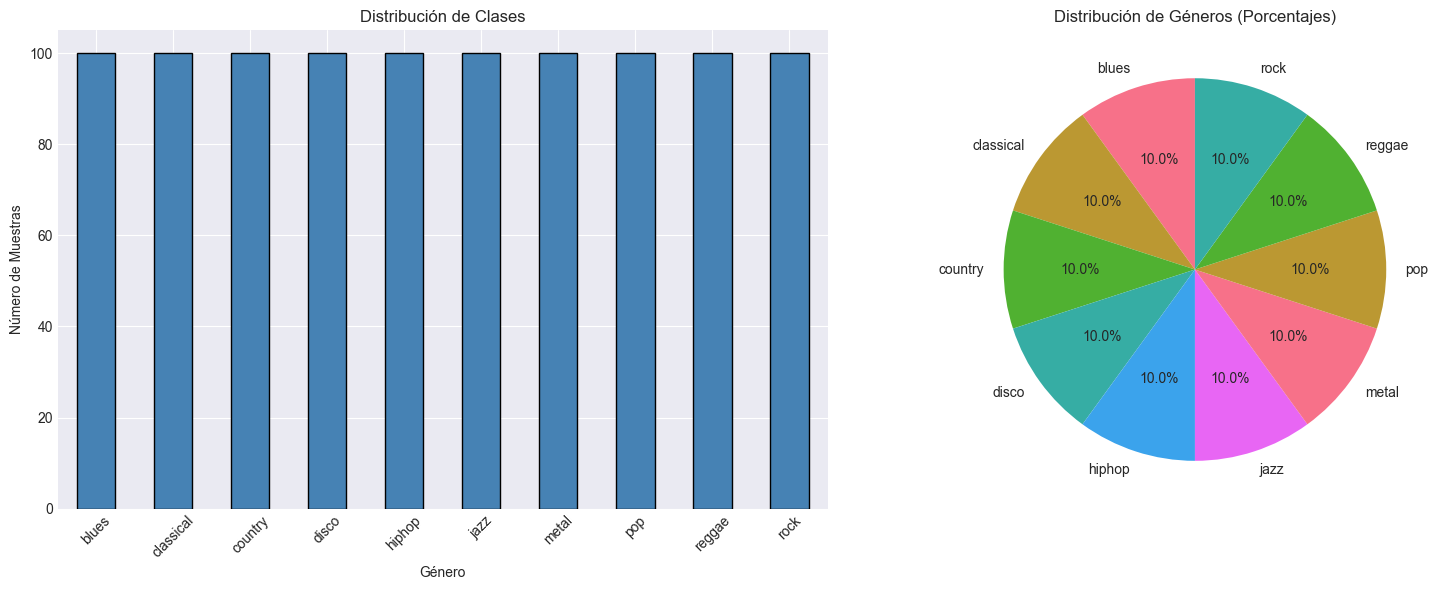


Análisis de Balance de Clases:
Min samples: 100
Max samples: 100
Imbalance ratio: 1.00
✓ El dataset está razonablemente balanceado.


In [5]:
# TODO: Analizar la distribución de la variable objetivo (genre)

# Identificar la columna objetivo (puede ser 'label', 'genre', etc.)
target_col = 'label'  # Actualizar según tu dataset
if target_col not in df.columns:
    target_col = 'genre'  # Probar nombre alternativo

print(f"Columna objetivo: {target_col}")
print(f"\nNumero de clases: {df[target_col].nunique()}")
print(f"\nDistribución de clases:")
class_counts = df[target_col].value_counts().sort_index()
print(class_counts)

# Visualizar la distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Número de Muestras')
axes[0].set_title('Distribución de Clases')
axes[0].tick_params(axis='x', rotation=45)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Distribución de Géneros (Porcentajes)')

plt.tight_layout()
plt.show()

# Check for class imbalance
print("\nAnálisis de Balance de Clases:")
min_samples = class_counts.min()
max_samples = class_counts.max()
imbalance_ratio = max_samples / min_samples
print(f"Min samples: {min_samples}")
print(f"Max samples: {max_samples}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 1.5:
    print("⚠️  El dataset está desbalanceado. Considera usar pesos de clase o re-muestreo.")
else:
    print("✓ El dataset está razonablemente balanceado.")

<span style="color:red">PON AQUÍ LAS CONCLUSIONES SOBRE LA VARIABLE OBJETIVO</span >

La variable objetivo está perfectamente balanceada. Cada género musical aparece exactamente 100 veces, por lo que no existe ningún tipo de desequilibrio entre clases. Esto es una gran ventaja porque el modelo no va a recibir más ejemplos de un género que de otro, y por tanto no tendrá tendencia a “preferir” una clase concreta.

Además, el número total de clases es diez, lo que indica que estamos ante un problema de clasificación multiclase, pero con categorías bien definidas y proporcionadas. Al no haber diferencias en la cantidad de muestras, no será necesario aplicar técnicas como re-muestreo, generación sintética de datos o el uso de pesos de clase. Todo esto facilita mucho el entrenamiento y permite que los resultados del modelo sean más fiables y comparables entre géneros.

## 1.3 Análisis Exploratorio de Datos (EDA)

### Análisis de Features de Audio

In [6]:
# TODO: Identificar y analizar las características de audio presentes en el dataset
# Características típicas: spectral_centroid, rolloff, zero_crossing_rate, mfcc, chroma, etc.

# Toma las columnas de características (excluye metadatos como filename, label, etc.)
metadata_cols = ['filename', 'label', 'genre']
feature_cols = [col for col in df.columns if col not in metadata_cols]

print(f"Número de features de audio: {len(feature_cols)}")
print("\nCategorías de features:")

# Categorize features
mfcc_features = [col for col in feature_cols if 'mfcc' in col.lower()]
chroma_features = [col for col in feature_cols if 'chroma' in col.lower()]
spectral_features = [col for col in feature_cols if any(x in col.lower() for x in ['spectral', 'rolloff', 'centroid'])]
temporal_features = [col for col in feature_cols if any(x in col.lower() for x in ['zero_crossing', 'tempo'])]

print(f"  MFCC features: {len(mfcc_features)}")
print(f"  Chroma features: {len(chroma_features)}")
print(f"  Spectral features: {len(spectral_features)}")
print(f"  Temporal features: {len(temporal_features)}")
print(f"  Otras features: {len(feature_cols) - len(mfcc_features) - len(chroma_features) - len(spectral_features) - len(temporal_features)}")

Número de features de audio: 58

Categorías de features:
  MFCC features: 40
  Chroma features: 2
  Spectral features: 6
  Temporal features: 3
  Otras features: 7


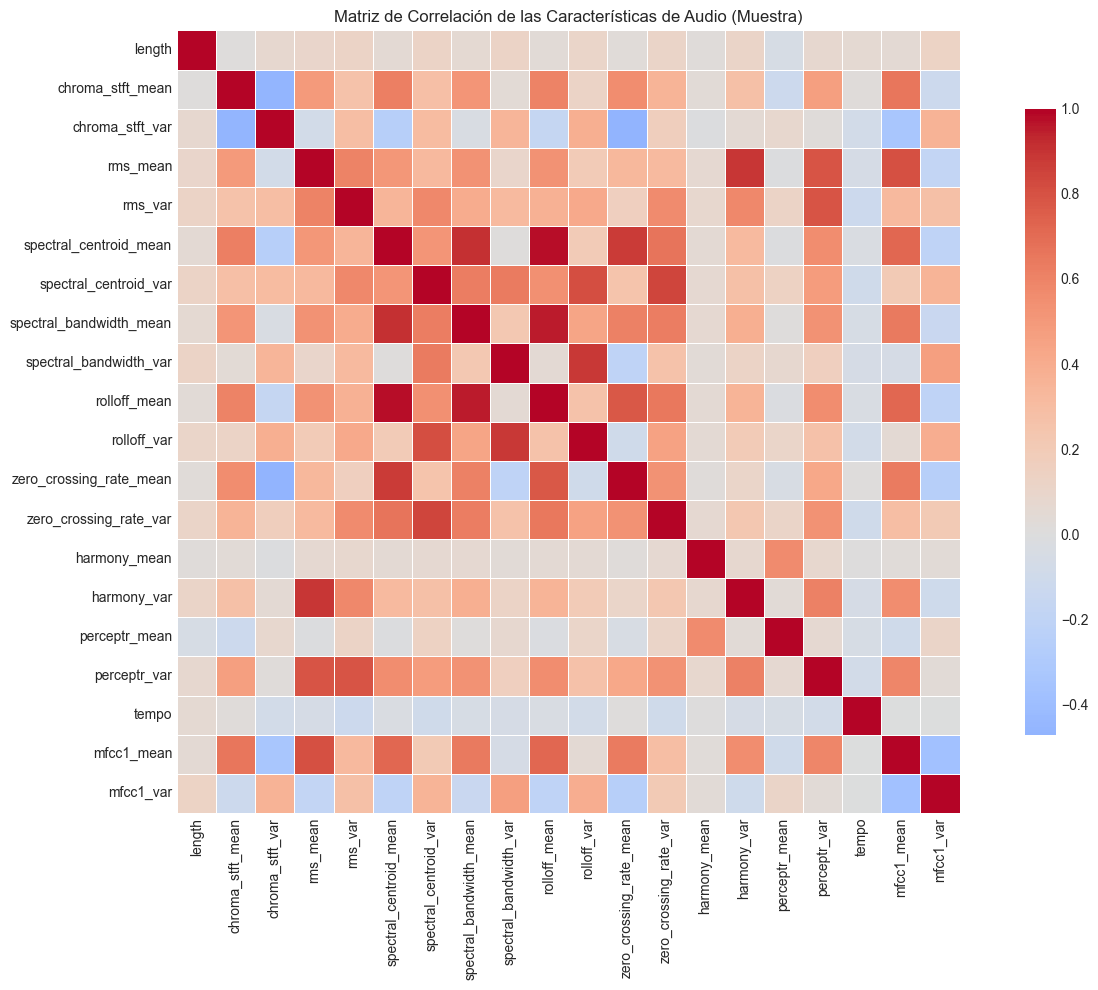


Se encontraron 3 pares de características altamente correlacionadas (|r| > 0.9):
  spectral_centroid_mean <-> spectral_bandwidth_mean: 0.904
  spectral_centroid_mean <-> rolloff_mean: 0.980
  spectral_bandwidth_mean <-> rolloff_mean: 0.956


In [7]:
# Matriz de correlación de las características de audio
sample_features = feature_cols[:20]  # Primeras 20 características para visualización
plt.figure(figsize=(14, 10))
correlation_matrix = df[sample_features].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación de las Características de Audio (Muestra)')
plt.tight_layout()
plt.show()

# Identificar características altamente correlacionadas
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"\nSe encontraron {len(high_corr_pairs)} pares de características altamente correlacionadas (|r| > 0.9):")
    for feat1, feat2, corr in high_corr_pairs[:5]:
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")

<span style="color:red">PON AQUÍ LAS CONCLUSIONES SOBRE EL EDA</span >

**Conclusiones del análisis de las características de audio**

El dataset contiene 58 características de audio diferentes. La mayoría de ellas (40) son MFCC, que son valores usados para describir el timbre del sonido y son muy comunes en tareas de clasificación musical. Además, el dataset incluye algunas características de chroma, que indican cómo se distribuyen las notas musicales, y varias características espectrales, que ayudan a entender qué tan brillante, agudo o grave es un audio. También hay algunas características temporales, relacionadas con el ritmo, como el tempo y la tasa de cruces por cero. En conjunto, el dataset tiene una buena variedad de información sobre el sonido, combinando timbre, ritmo, tono y energía.

**Conclusiones del análisis de correlación**

Al analizar la correlación entre las características, se observaron algunos pares que están muy fuertemente relacionados entre sí (correlación mayor a 0.9). Esto ocurre principalmente entre medidas espectrales, como el spectral centroid, el spectral bandwidth y el rolloff. Esto es normal, ya que todas estas características describen diferentes aspectos del espectro de frecuencias del audio, por lo que es habitual que se parezcan mucho entre sí.

En resumen, aunque el dataset tiene muchas características, algunas de ellas están dando información muy similar. Esto puede causar redundancia.

---
## 1.4 Preprocesamiento de Datos

### Manejar Valores Ausentes

<span style="color:red">COMENTA TU ESTRATEGIA PARA MANEJAR LOS VALORES FALTANTES Y EL RESULTADO DE ESTA</span >

Se ha realizado la limpieza de valores ausentes del dataset. Se eliminaron todas las filas donde la variable objetivo (`target_col`) estaba vacía para asegurar que el modelo tenga siempre un valor de referencia. Para las características de audio, los valores faltantes se reemplazaron por la **media de su respectiva columna**, manteniendo la información útil sin introducir sesgos importantes. Finalmente, se comprobó la forma del dataset, el número de filas eliminadas y que no quedaran valores ausentes, garantizando que los datos estén listos para el entrenamiento del modelo.


In [8]:
# TODO: Implementar estrategias de manejo de valores ausentes

df_clean = df.copy()

# Eliminar filas donde la variable objetivo esté ausente
df_clean = df_clean.dropna(subset=[target_col])

# Para las características, usar imputación por la media
for col in feature_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].mean(), inplace=True)

print(f"Forma del dataset después de la limpieza: {df_clean.shape}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")
print(f"Valores ausentes restantes: {df_clean.isnull().sum().sum()}")

Forma del dataset después de la limpieza: (1000, 60)
Filas eliminadas: 0
Valores ausentes restantes: 0


### Ingeniería de Características (Feature Engineering)

<span style="color:red">COMENTA TU INGENIERÍA DE CARACTERÍSTICAS</span >

En esta etapa de ingeniería de características, se han creado nuevas variables que buscan aportar información más relevante para el modelo. Se han generado ratios entre características relacionadas, como `spectral_contrast_ratio` y `rms_perceptr_ratio`, para capturar relaciones relativas entre energía percibida y medidas espectrales. Además, se han agregado estadísticas derivadas de los coeficientes MFCC, como `mfcc_std` y `mfcc_std_10`, que resumen la variabilidad y el rango del timbre de la pista, permitiendo al modelo captar patrones más complejos en el dominio tímbrico. Estas transformaciones enriquecen el conjunto de datos, ayudando al modelo a aprender de manera más efectiva sin depender únicamente de las características originales.


In [9]:
print("Features antes de ingeniería:", df_clean.shape[1])

# TODO: Crear nuevas features si fuera necesario

# Ejemplo de features:
# - Ratios entre diferentes características de audio
# - Estadísticas agregadas de los coeficientes MFCC
# - Interacciones entre características espectrales

# Ejemplo: Ratio de contraste espectral
if 'spectral_centroid_mean' in df_clean.columns and 'spectral_rolloff_mean' in df_clean.columns:
    df_clean['spectral_contrast_ratio'] = (df_clean['spectral_rolloff_mean'] / 
                                            (df_clean['spectral_centroid_mean'] + 1))

# Ejemplo: Estadísticas de MFCC si los MFCC individuales están disponibles
mfcc_cols = [col for col in df_clean.columns if 'mfcc' in col.lower() and col != 'mfcc_mean']
if len(mfcc_cols) > 5:
    df_clean['mfcc_std'] = df_clean[mfcc_cols[:10]].std(axis=1)
    df_clean['mfcc_range'] = df_clean[mfcc_cols[:10]].max(axis=1) - df_clean[mfcc_cols[:10]].min(axis=1)

# TODO: Agrega tus propias ideas de ingeniería de características

# Ratio simple: RMS sobre energía percibida (perceptr_mean)
df_clean['rms_perceptr_ratio'] = df_clean['rms_mean'] / (df_clean['perceptr_mean'] + 1e-6)  # + 1e-6 para evitar dividir entre cero por si perceptr_mean = 0

# Desviación estándar de los primeros 10 MFCC
mfcc_cols = []
for i in range(1, 11):
    mfcc_cols.append('mfcc' + str(i) + '_mean')
df_clean['mfcc_std_10'] = df_clean[mfcc_cols].std(axis=1)


print("Features tras ingeniería:", df_clean.shape[1])

Features antes de ingeniería: 60
Features tras ingeniería: 64


### Codificar Variables Categóricas y Variable Objetivo

<span style="color:red">COMENTA TU ESTRATEGIA PARA MANEJAR CADA VARIABLE CATEGÓRICA</span >

Todas las variables son numéricas, la única categórica es la variable objetivo.

La estrategia empleada trata de separar las características y la variable objetivo, codificar los géneros musicales en números. Una vez hecho esto, se muestra información sobre clases, features y tamaño del dataset.


In [10]:
# TODO: Codificar variables categóricas y variable objetivo

# Separar features y variable objetivo
X = df_clean.drop(columns=[target_col, 'filename'])
y = df_clean[target_col]


# Codificar etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Codificación de etiquetas:")
for idx, genre in enumerate(label_encoder.classes_):
    print(f"  {genre}: {idx}")

# Guardar información sobre las clases
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_

print(f"\nNumero de clases: {num_classes}")
print(f"Numero de features: {X.shape[1]}")
print(f"Total de muestras: {len(X)}")

Codificación de etiquetas:
  blues: 0
  classical: 1
  country: 2
  disco: 3
  hiphop: 4
  jazz: 5
  metal: 6
  pop: 7
  reggae: 8
  rock: 9

Numero de clases: 10
Numero de features: 62
Total de muestras: 1000


### Conjunto de Entrenamiento, Validación y Test

**Entrenamiento de modelos:** Más adelante en el notebook, en los ENTRENAMIENTOS, usaremos y_train_cat, y_val_cat porque la red esperará one-hot ya que tendremos modelos con capa de salida softmax.

**Evaluación con evaluate_classifier:** Pasaremos y_test (enteros) porque la función hace argmax y compara con etiquetas normales.

<span style="color:red">JUSTIFICA EL PARTICIONADO USADO Y SUS VALORES/PORCENTAJES</span >

Se dividió el dataset en **70% entrenamiento** y **30% temporal**, de los cuales se tomó la mitad para **validación** y la otra mitad para **test** (15% cada uno). Esto asegura suficientes datos para entrenar y, al mismo tiempo, evaluar el modelo. Se aplicó **estratificación** para mantener la proporción de géneros en cada conjunto, evitando que algunas clases queden subrepresentadas y garantizando una evaluación más confiable.


In [11]:
# TODO: Dividir datos en conjuntos de entrenamiento, validación y test
# Usar estratificación para mantener la distribución de clases

# Ejemplo: primera división: 70% entrenamiento, 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Segunda división: dividir temporal en validación (50%) y prueba (50%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Particionado de datos:")
print(f"Conjunto de Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Conjunto de Validación: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Conjunto de Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Comprobar estratificación
print("\nDistribución de clases en los conjuntos:")
for split_name, split_data in [('Entrenamiento', y_train), ('Validación', y_val), ('Test', y_test)]:
    unique, counts = np.unique(split_data, return_counts=True)
    percentages = counts / len(split_data) * 100
    print(f"\n{split_name}:")
    for cls, pct in zip(unique, percentages):
        print(f"  {class_names[cls]}: {pct:.1f}%")

Particionado de datos:
Conjunto de Entrenamiento: 700 muestras (70.0%)
Conjunto de Validación: 150 muestras (15.0%)
Conjunto de Test: 150 muestras (15.0%)

Distribución de clases en los conjuntos:

Entrenamiento:
  blues: 10.0%
  classical: 10.0%
  country: 10.0%
  disco: 10.0%
  hiphop: 10.0%
  jazz: 10.0%
  metal: 10.0%
  pop: 10.0%
  reggae: 10.0%
  rock: 10.0%

Validación:
  blues: 10.0%
  classical: 10.0%
  country: 10.0%
  disco: 10.0%
  hiphop: 10.0%
  jazz: 10.0%
  metal: 10.0%
  pop: 10.0%
  reggae: 10.0%
  rock: 10.0%

Test:
  blues: 10.0%
  classical: 10.0%
  country: 10.0%
  disco: 10.0%
  hiphop: 10.0%
  jazz: 10.0%
  metal: 10.0%
  pop: 10.0%
  reggae: 10.0%
  rock: 10.0%


### Escalado de Características

<span style="color:red">COMENTA LA NORMALIZACIÓN/ESTANDARIZACIÓN DE LOS DATOS</span >

Aquí se ha realizado la estandarización de los datos. Esto significa que todas las características se han transformado para que tengan media 0 y desviación estándar 1, lo cual ayuda a que la red neuronal aprenda mejor y más rápido. Es importante que el scaler se ajuste solo con los datos de entrenamiento (fit_transform) y luego se aplique a validación y test (transform) para evitar filtración de información. Los print finales confirman que la media y la desviación estándar de los datos transformados son aproximadamente 0 y 1, respectivamente.

In [12]:
# TODO: Probar estandarización o normalización de datos, según convenga

# Ejemplo: Estandarización (mean=0, std=1)
scaler = StandardScaler()

# Ajustar solo con datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Estandarización de características completada!")
print(f"Media de características después de la estandarización (debería ser ~0): {X_train_scaled.mean():.6f}")
print(f"Desviación estándar de características después de la estandarización (debería ser ~1): {X_train_scaled.std():.6f}")

Estandarización de características completada!
Media de características después de la estandarización (debería ser ~0): 0.000000
Desviación estándar de características después de la estandarización (debería ser ~1): 1.000000


### Preparar Etiquetas con Codificación One-Hot

<span style="color:red">COMENTA EL ETIQUETADO CON ONE-HOT A REALIZAR</span >

Se ha realizado la codificación **one-hot** de las etiquetas de los géneros musicales. Esto significa que cada etiqueta numérica (por ejemplo, “0” para blues, “1” para classical, etc.) se transforma en un vector donde todos los valores son cero excepto en la posición correspondiente a su clase, que se pone a uno. Por ejemplo, si tenemos 10 clases, la etiqueta 3 se convierte en `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`. Esta representación es necesaria para las redes neuronales cuando se usa una función de pérdida como **categorical crossentropy**, ya que permite que el modelo aprenda a predecir probabilidades para cada clase de manera independiente.


In [13]:
# TODO: Convertir las etiquetas a codificación one-hot si es necesario para la red neuronal

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Forma de las etiquetas codificadas en one-hot: {y_train_cat.shape}")
print(f"Ejemplo: Etiqueta {y_train[0]} ({class_names[y_train[0]]}) -> {y_train_cat[0]}")

Forma de las etiquetas codificadas en one-hot: (700, 10)
Ejemplo: Etiqueta 8 (reggae) -> [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


---
# Parte 2: Modelos Baseline

## 2.1 Baselines Sencillos

In [14]:
# TODO: Implementar modelos baseline

# Baseline 1: Majority class prediction
from collections import Counter
most_common_class = Counter(y_train).most_common(1)[0][0]
majority_pred = np.full(len(y_test), most_common_class)
majority_acc = accuracy_score(y_test, majority_pred)

print("Baseline 1: Majority Class Prediction")
print(f"  Accuracy: {majority_acc:.4f} ({majority_acc*100:.2f}%)")

# Baseline 2: Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print("\nBaseline 2: Logistic Regression")
print(f"  Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

# Baseline 3: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, rf_pred)

print("\nBaseline 3: Random Forest")
print(f"  Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)")

# Summary table
baseline_results = pd.DataFrame({
    'Model': ['Majority Class', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [majority_acc, lr_acc, rf_acc]
})

Baseline 1: Majority Class Prediction
  Accuracy: 0.1000 (10.00%)

Baseline 2: Logistic Regression
  Accuracy: 0.7400 (74.00%)

Baseline 3: Random Forest
  Accuracy: 0.7600 (76.00%)


In [15]:
print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS BASELINE")
print("="*50)
display(baseline_results)


COMPARACIÓN DE MODELOS BASELINE


,Model,Accuracy
0,Majority Class,0.10
1,Logistic Regression,0.74
2,Random Forest,0.76


In [16]:
# Resultado detallado del Random Forest
print("\nRandom Forest - Resultado Detallado:")
print(classification_report(y_test, rf_pred, target_names=class_names))


Random Forest - Resultado Detallado:
              precision    recall  f1-score   support

       blues       0.82      0.60      0.69        15
   classical       0.78      0.93      0.85        15
     country       0.56      0.60      0.58        15
       disco       0.92      0.80      0.86        15
      hiphop       0.75      0.80      0.77        15
        jazz       0.75      0.80      0.77        15
       metal       0.78      0.93      0.85        15
         pop       0.88      0.93      0.90        15
      reggae       0.73      0.73      0.73        15
        rock       0.64      0.47      0.54        15

    accuracy                           0.76       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.76      0.76      0.76       150



## 2.2 Red Neuronal Sencilla

In [17]:
# TODO: Construye un modelo de red neuronal simple para clasificación multiclase
# TODO: Indicar número de neuronas y función de activación en la arquitectura comentada

def create_simple_classifier(input_dim, num_classes):
    """
    Create a simple feedforward neural network for regression.
    
    Architecture:
    - Input Layer: recibe las features del dataset
    - Hidden Layer 1: 16 neuronas, función de activación ReLU
    - Hidden Layer 2: 16 neuronas, función de activación ReLU
    - Output Layer: 1 neurona, con función de activación softmax (convierte en vector de probabilidades), ideal para clasificación
    """

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax') # Softmax convierte un vector de números en un vector de probabilidades que suman 1. Ideal para clasificación.
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

input_dim = X_train_scaled.shape[1]




Entrenando red neuronal con seed = 0...


simple_nn_seed_0 Evaluation
Accuracy: 0.6267 (62.67%)

              precision    recall  f1-score   support

       blues       0.50      0.47      0.48        15
   classical       0.86      0.80      0.83        15
     country       0.44      0.47      0.45        15
       disco       0.56      0.67      0.61        15
      hiphop       0.67      0.80      0.73        15
        jazz       0.65      0.73      0.69        15
       metal       0.75      0.80      0.77        15
         pop       0.82      0.60      0.69        15
      reggae       0.47      0.53      0.50        15
        rock       0.67      0.40      0.50        15

    accuracy                           0.63       150
   macro avg       0.64      0.63      0.62       150
weighted avg       0.64      0.63      0.62       150



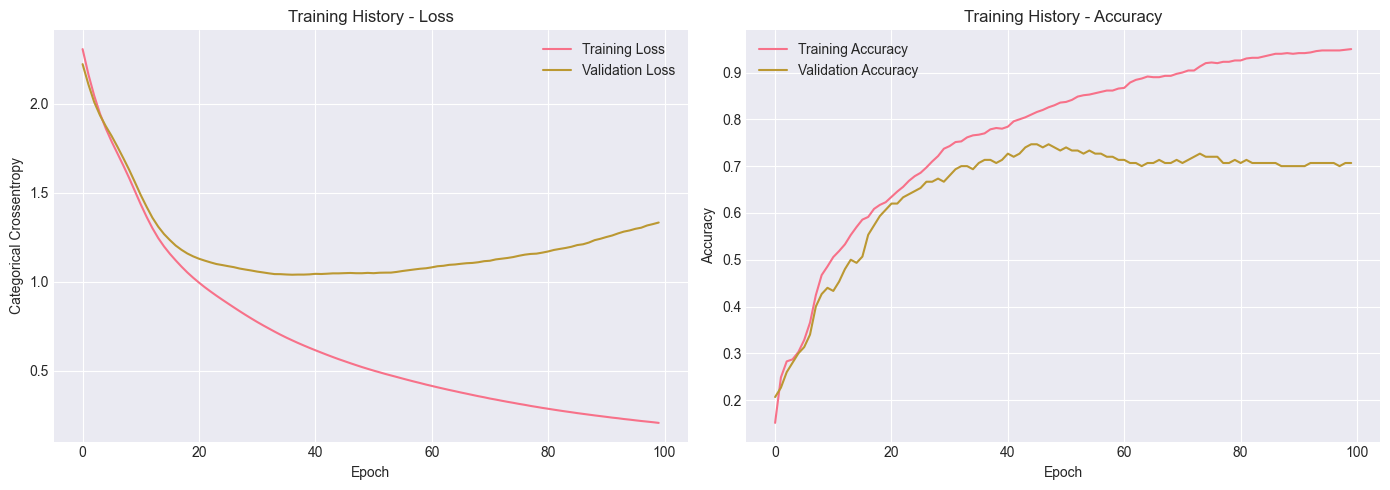

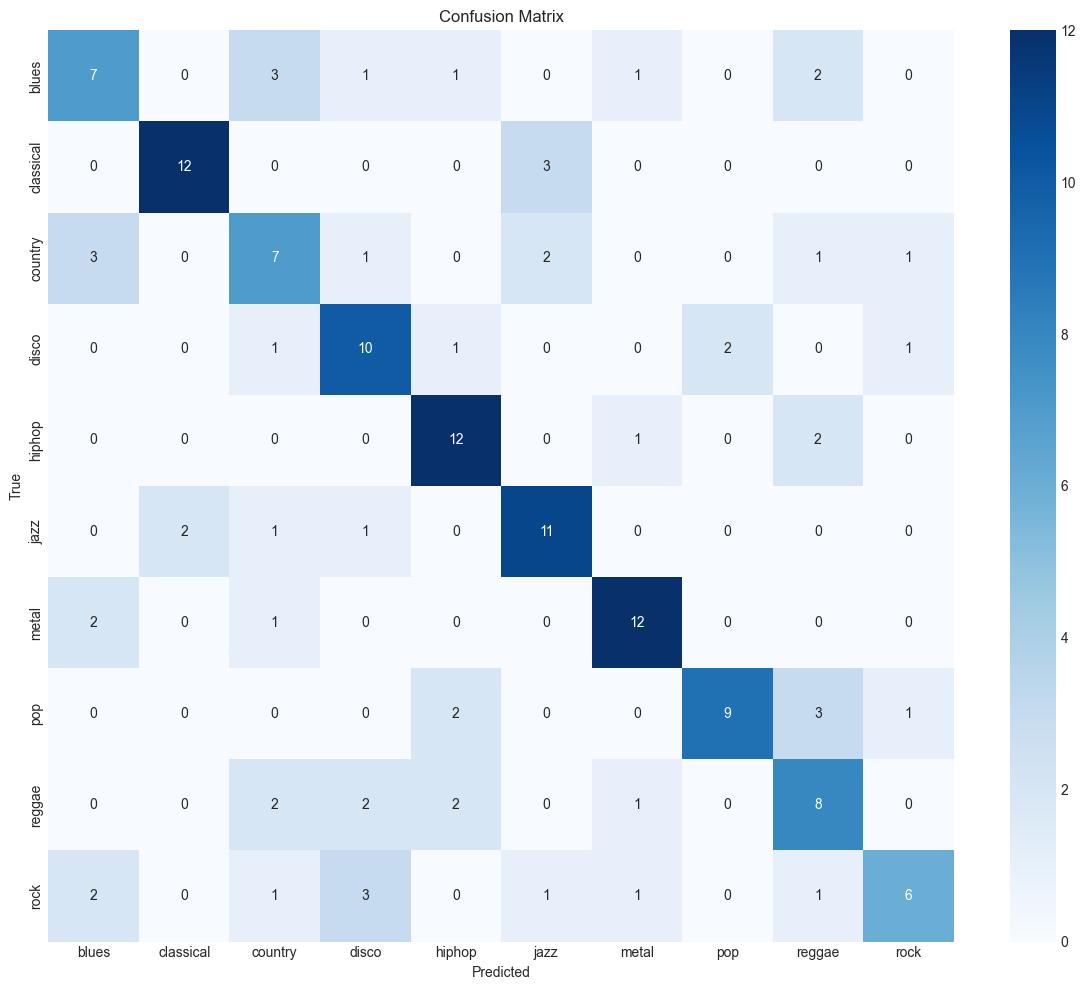


Entrenando red neuronal con seed = 1...


simple_nn_seed_1 Evaluation
Accuracy: 0.7200 (72.00%)

              precision    recall  f1-score   support

       blues       0.77      0.67      0.71        15
   classical       0.93      0.93      0.93        15
     country       0.70      0.47      0.56        15
       disco       0.53      0.53      0.53        15
      hiphop       0.77      0.67      0.71        15
        jazz       0.78      0.93      0.85        15
       metal       0.74      0.93      0.82        15
         pop       0.81      0.87      0.84        15
      reggae       0.58      0.73      0.65        15
        rock       0.58      0.47      0.52        15

    accuracy                           0.72       150
   macro avg       0.72      0.72      0.71       150
weighted avg       0.72      0.72      0.71       150



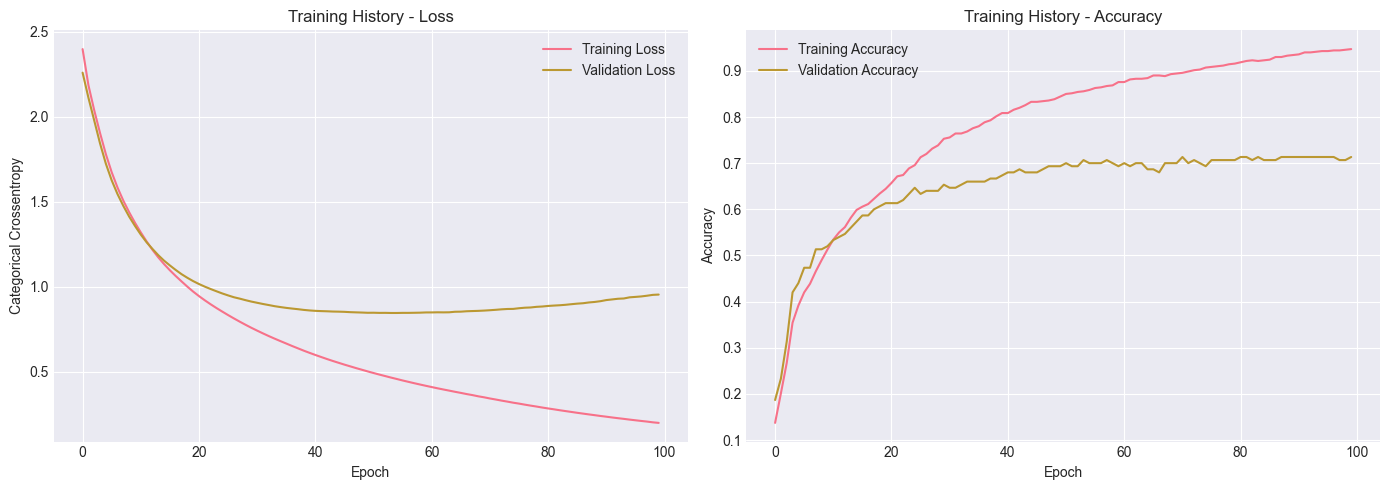

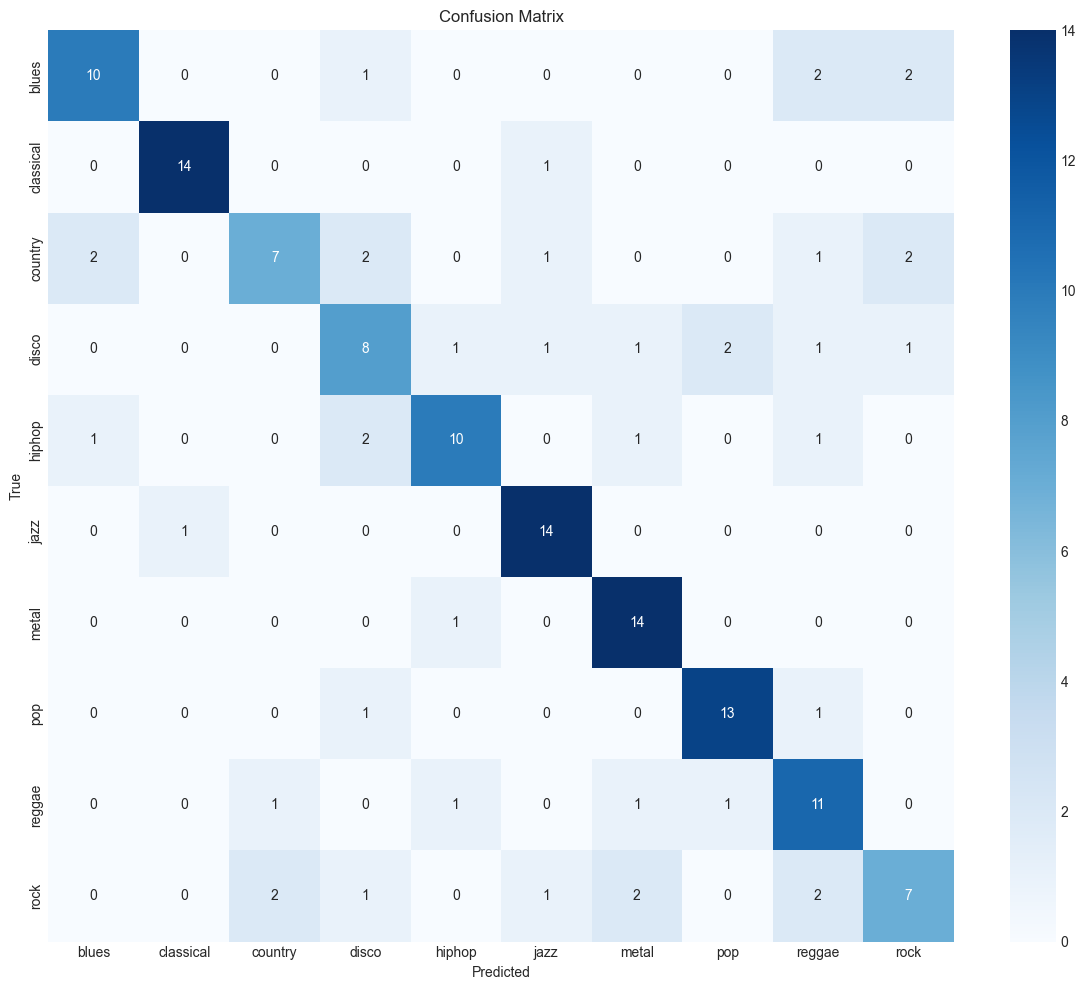


Entrenando red neuronal con seed = 2...


simple_nn_seed_2 Evaluation
Accuracy: 0.6800 (68.00%)

              precision    recall  f1-score   support

       blues       0.67      0.53      0.59        15
   classical       0.87      0.87      0.87        15
     country       0.47      0.60      0.53        15
       disco       0.64      0.60      0.62        15
      hiphop       0.79      0.73      0.76        15
        jazz       0.76      0.87      0.81        15
       metal       0.87      0.87      0.87        15
         pop       0.82      0.60      0.69        15
      reggae       0.50      0.80      0.62        15
        rock       0.56      0.33      0.42        15

    accuracy                           0.68       150
   macro avg       0.69      0.68      0.68       150
weighted avg       0.69      0.68      0.68       150



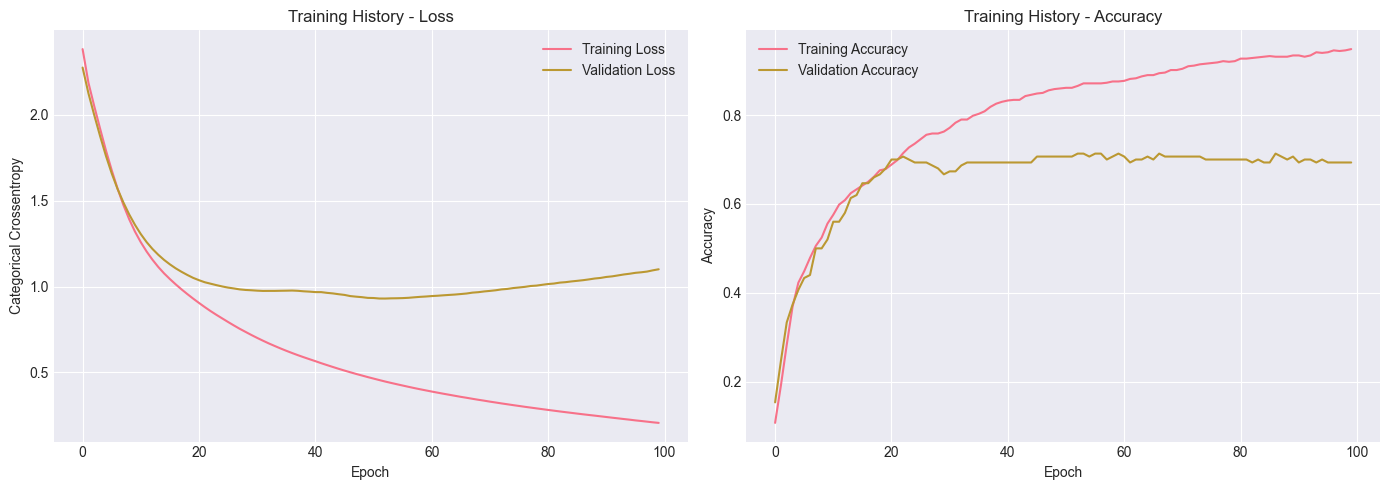

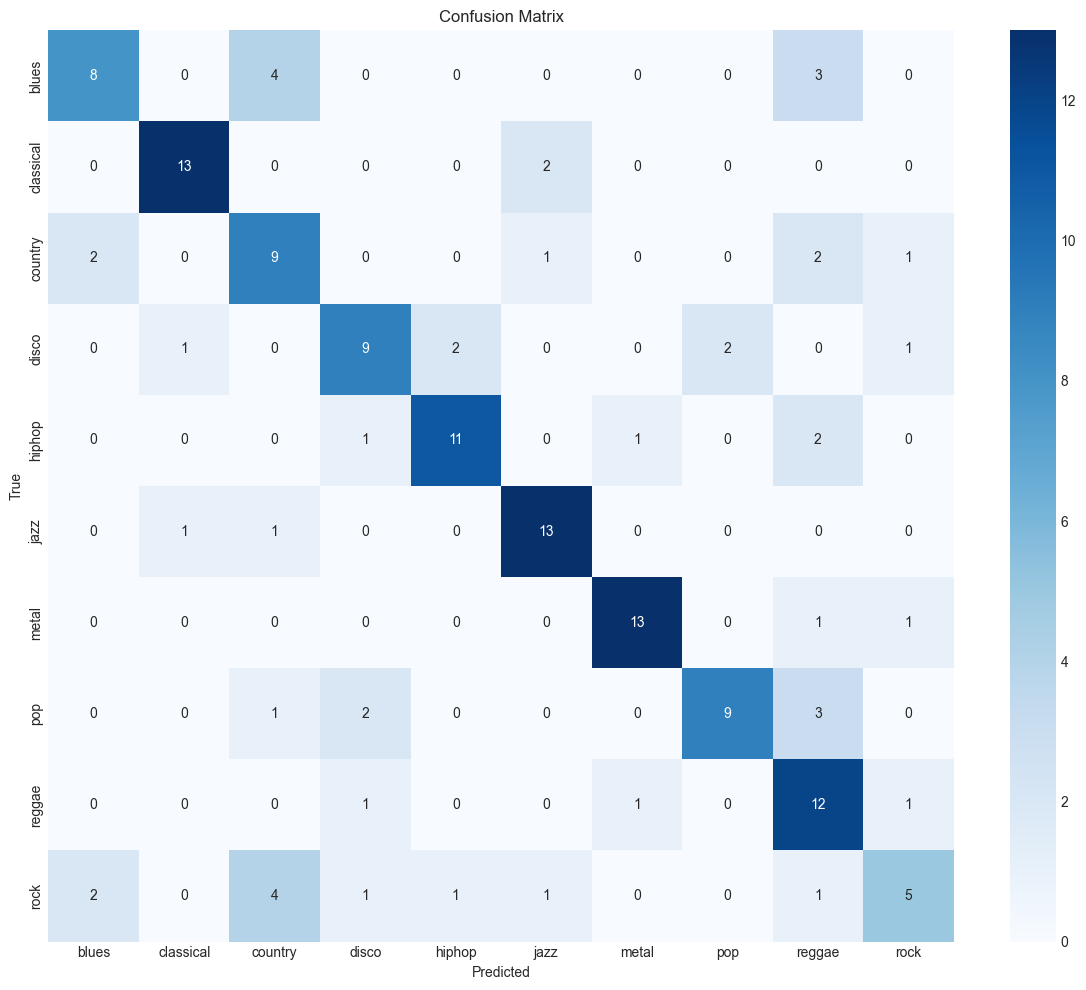

In [18]:
# TODO: Entrenar (fit) el modelo simple
# TODO: Evaluar el modelo con el conjunto de test. Consejo: usar la función evaluate_classifier definida anteriormente

#############################
seeds = [0, 1, 2]
results = []
accuracies_test = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)   # Fija la semilla en todas las librerías

    # Crear el modelo con la arquitectura dada
    model = create_simple_classifier(input_dim, num_classes)

    print(f"\nEntrenando red neuronal con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0,
    )

    # Evaluar y guardar los resultados
    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"simple_nn_seed_{seed}")
    results.append(result)
    accuracies_test.append(result['Accuracy'])
    
    # Graficar entrenamiento
    plot_training_history_classification(history)

    # Matriz de confusión
    plot_confusion_matrix_custom(y_test, result['Predictions'], class_names)

In [19]:
# TODO: Comparar resultados del modelo neuronal simple con los modelos baseline
comparison_df = pd.DataFrame({
    'Modelo': ['Majority Class', 'Logistic Regression', 'Random Forest'] + [f'Red Neuronal (seed={s})' for s in seeds],
    'Accuracy': [majority_acc, lr_acc, rf_acc] + accuracies_test
})

comparison_df


,Modelo,Accuracy
0,Majority Class,0.100000
1,Logistic Regression,0.740000
2,Random Forest,0.760000
3,Red Neuronal (seed=0),0.626667
4,Red Neuronal (seed=1),0.720000
5,Red Neuronal (seed=2),0.680000


In [20]:
# TODO: Mostrar gráficos de entrenamiento (loss, Accuracy, etc.). Consejo: usar las funciones plot_training_history_classification y plot_confusion_matrix definidas anteriormente

# (HECHO YA EN CELDAS ANTERIORES)

<span style="color:red">COMENTA LOS RESULTADOS OBTENIDOS CON LA RED NEURONAL SIMPLE, SU COMPARACIÓN CON MODELOS ANTERIORES Y QUÉ SE PUEDE MEJORAR.</span >

Los resultados obtenidos con la red neuronal simple muestran que el modelo **aprendió a reconocer patrones en los datos de entrenamiento**, ya que la training loss disminuye y la accuracy de entrenamiento sube, lo que indica que se ajusta bien a los ejemplos que ha visto. Sin embargo, en el conjunto de validación, la loss se mantiene más alta y la accuracy más baja y, aunque mejora a lo largo de las épocas, no llega a alcanzar los buenos resultados del conjunto de entrenamiento. Esto indica que el modelo no generaliza del todo bien a datos nuevos, es decir, aprende las características del conjunto de entrenamiento pero no logra trasladar del todo ese aprendizaje con la misma eficacia al conjunto de validación. Aun así, los resultados en el conjunto de validación no son especialmente malos.

Al comparar con los modelos anteriores, la red neuronal simple **no supera a la regresión logística ni al random forest**; ambos modelos clásicos logran accuracies más altas que la red neuronal. Esto indica que, con la arquitectura tan básica que usamos, la red todavía no aprovecha todo su potencial y necesita mejoras en la estructura, regularización, optimización, etc.

La matriz de confusión muestra que, en general, **la mayoría de los valores de la diagonal son altos**, lo que indica que muchas clases se clasifican correctamente. Sin embargo, **hay algunas clases cuya diagonal no es tan alta**, lo que significa que esas clases se confunden más fácilmente con otras. Por otro lado, **los valores fuera de la diagonal son bajos**, lo que indica que los errores graves son pocos y que el modelo raramente predice clases completamente equivocadas. Esto confirma que, aunque la red neuronal simple captura patrones generales, todavía tiene dificultades con algunas clases específicas y necesita ajustes para mejorar la generalización.

---
# Parte 3: Exploración de Arquitectura y Detección de problemas


<span style="color:red">COMENTA TU PROCEDIMINTO PARA PROBAR DISTINTAS ARQUITECTURAS (NUMERO DE CAPAS Y NEURONAS, FUNCIONES DE ACTIVACION, MODO DE ENTRENAMIENTO, FUNCIONES DE PERDIDA/COSTE, FACTOR DE APRENDIZAJE)</span >

<span style="color:red">EN CADA UNA DE ELLAS, COMENTA LOS RESULTADOS OBTENIDOS Y DETECTA POSIBLES PROBLEMAS (E.G. OVERFITTING, UNDERFITTING, GRADIENT VANISHING, ETC.)</span >

**ARQUITECTURA 1**

Aumentamos el número de neuronas en cada capa.

In [21]:
# Definir la arquitectura del modelo arch1
def create_model_arch1(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3]
results_arch1 = []
accuracies_arch1 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch1(input_dim, num_classes)

    print(f"\nEntrenando arch1 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch1_seed_{seed}")
    results_arch1.append(result)
    accuracies_arch1.append(result['Accuracy'])


Entrenando arch1 con seed = 0...


arch1_seed_0 Evaluation
Accuracy: 0.6467 (64.67%)

              precision    recall  f1-score   support

       blues       0.73      0.53      0.62        15
   classical       0.92      0.80      0.86        15
     country       0.53      0.60      0.56        15
       disco       0.42      0.33      0.37        15
      hiphop       0.76      0.87      0.81        15
        jazz       0.59      0.67      0.62        15
       metal       0.81      0.87      0.84        15
         pop       0.75      0.80      0.77        15
      reggae       0.59      0.67      0.62        15
        rock       0.36      0.33      0.34        15

    accuracy                           0.65       150
   macro avg       0.65      0.65      0.64       150
weighted avg       0.65      0.65      0.64       150


Entrenando arch1 con seed = 1...


arch1_seed_1 Evaluation
Accuracy: 0.6933 (69.33%)

              precision    recall  f1-score   support

       blues

In [22]:
# Comparación de arch1 con modelos baseline
comparison_arch1_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch1 (seed=0)', 
        'Arch1 (seed=1)', 
        'Arch1 (seed=2)', 
        'Arch1 (seed=3)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch1[0], 
        accuracies_arch1[1], 
        accuracies_arch1[2], 
        accuracies_arch1[3]
    ]
})

comparison_arch1_df


,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch1 (seed=0),0.646667
3,Arch1 (seed=1),0.693333
4,Arch1 (seed=2),0.700000
5,Arch1 (seed=3),0.686667


Parece que se puede seguir mejorando la accuracy porque no se ha mejorado mucho, probemos a aumentar el número de capas.

**ARQUITECTURA 2**

Aumentamos el número de capas.

In [23]:
# Definir la arquitectura del modelo arch2
def create_model_arch2(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3]
results_arch2 = []
accuracies_arch2 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch2(input_dim, num_classes)

    print(f"\nEntrenando arch2 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch2_seed_{seed}")
    results_arch2.append(result)
    accuracies_arch2.append(result['Accuracy'])



Entrenando arch2 con seed = 0...


arch2_seed_0 Evaluation
Accuracy: 0.7133 (71.33%)

              precision    recall  f1-score   support

       blues       0.73      0.73      0.73        15
   classical       0.79      0.73      0.76        15
     country       0.60      0.60      0.60        15
       disco       0.56      0.60      0.58        15
      hiphop       0.79      0.73      0.76        15
        jazz       0.72      0.87      0.79        15
       metal       0.86      0.80      0.83        15
         pop       0.81      0.87      0.84        15
      reggae       0.65      0.73      0.69        15
        rock       0.64      0.47      0.54        15

    accuracy                           0.71       150
   macro avg       0.71      0.71      0.71       150
weighted avg       0.71      0.71      0.71       150


Entrenando arch2 con seed = 1...


arch2_seed_1 Evaluation
Accuracy: 0.6867 (68.67%)

              precision    recall  f1-score   support

       blues

In [24]:
# Comparación de arch2 con modelos baseline
comparison_arch2_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch2 (seed=0)', 
        'Arch2 (seed=1)', 
        'Arch2 (seed=2)', 
        'Arch2 (seed=3)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch2[0], 
        accuracies_arch2[1], 
        accuracies_arch2[2], 
        accuracies_arch2[3]
    ]
})

comparison_arch2_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch2 (seed=0),0.713333
3,Arch2 (seed=1),0.686667
4,Arch2 (seed=2),0.680000
5,Arch2 (seed=3),0.706667


Aunque se ha mejorado la accuracy, podemos optimizar la configuración de las neuronas. Es lo que haremos en la siguiente arquitectura.

**ARQUITECTURA 3**

Mejoramos la configuración de las neuronas en las capas.

In [25]:
# Definir la arquitectura del modelo arch3
def create_model_arch3(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3]
results_arch3 = []
accuracies_arch3 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch3(input_dim, num_classes)

    print(f"\nEntrenando arch3 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch3_seed_{seed}")
    results_arch3.append(result)
    accuracies_arch3.append(result['Accuracy'])



Entrenando arch3 con seed = 0...


arch3_seed_0 Evaluation
Accuracy: 0.6800 (68.00%)

              precision    recall  f1-score   support

       blues       0.77      0.67      0.71        15
   classical       0.80      0.80      0.80        15
     country       0.71      0.67      0.69        15
       disco       0.62      0.53      0.57        15
      hiphop       0.71      0.67      0.69        15
        jazz       0.67      0.80      0.73        15
       metal       0.76      0.87      0.81        15
         pop       0.75      0.80      0.77        15
      reggae       0.55      0.73      0.63        15
        rock       0.40      0.27      0.32        15

    accuracy                           0.68       150
   macro avg       0.67      0.68      0.67       150
weighted avg       0.67      0.68      0.67       150


Entrenando arch3 con seed = 1...


arch3_seed_1 Evaluation
Accuracy: 0.7267 (72.67%)

              precision    recall  f1-score   support

       blues

In [26]:
# Comparación de arch3 con modelos baseline
comparison_arch3_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch3 (seed=0)', 
        'Arch3 (seed=1)', 
        'Arch3 (seed=2)', 
        'Arch3 (seed=3)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch3[0], 
        accuracies_arch3[1], 
        accuracies_arch3[2], 
        accuracies_arch3[3]
    ]
})

comparison_arch3_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch3 (seed=0),0.680000
3,Arch3 (seed=1),0.726667
4,Arch3 (seed=2),0.713333
5,Arch3 (seed=3),0.706667


Debido al tamaño del dataframe, no vamos a seguir añadiendo capas y neuronas, porque surgirá OVERFITTING, por lo tanto, como estos resultados ya se acercan bastante a los modelos baseline, partiremos de esta arquitectura para probar a cambiar el learning rate para ver si podemos mejorarlo. La `arquitectura 3` usa el learing rate por defecto de adam: `lr = 0.001`, veamos si podemos encontrar un mejor valor, o este es el mejor posible.

**ARQUITECTURA 3.1**

`Arquitectura 3` pero con learning rate bajo.

Al reducir el learning rate en la Arquitectura 3, estamos haciendo que el modelo actualice sus pesos de manera más suave y controlada durante el entrenamiento. Esto significa que los pasos de ajuste son más pequeños, lo que puede ayudar a evitar saltos grandes que empeoren la convergencia y permite que el modelo encuentre un mínimo más estable de la función de pérdida. Sin embargo, un learning rate demasiado bajo también puede ralentizar mucho el entrenamiento y hacer que el modelo no alcance buenos resultados. Veamos qué pasa.

In [27]:
# Definir la arquitectura del modelo arch_3_1
def create_model_arch_3_1(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_1 = []
accuracies_arch_3_1 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_1(input_dim, num_classes)

    print(f"\nEntrenando arch_3_1 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_1_seed_{seed}")
    results_arch_3_1.append(result)
    accuracies_arch_3_1.append(result['Accuracy'])



Entrenando arch_3_1 con seed = 0...


arch_3_1_seed_0 Evaluation
Accuracy: 0.7267 (72.67%)

              precision    recall  f1-score   support

       blues       0.83      0.67      0.74        15
   classical       0.81      0.87      0.84        15
     country       0.82      0.60      0.69        15
       disco       0.65      0.73      0.69        15
      hiphop       0.67      0.67      0.67        15
        jazz       0.71      0.80      0.75        15
       metal       0.93      0.93      0.93        15
         pop       0.85      0.73      0.79        15
      reggae       0.55      0.73      0.63        15
        rock       0.57      0.53      0.55        15

    accuracy                           0.73       150
   macro avg       0.74      0.73      0.73       150
weighted avg       0.74      0.73      0.73       150


Entrenando arch_3_1 con seed = 1...


arch_3_1_seed_1 Evaluation
Accuracy: 0.7133 (71.33%)

              precision    recall  f1-score   support



In [28]:
# Comparación de arch_3_1 con modelos baseline incluyendo todas las seeds
comparison_arch_3_1_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.1 (seed=0)', 
        'Arch_3.1 (seed=1)', 
        'Arch_3.1 (seed=2)', 
        'Arch_3.1 (seed=3)',
        'Arch_3.1 (seed=4)',
        'Arch_3.1 (seed=5)',
        'Arch_3.1 (seed=6)',
        'Arch_3.1 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_1[0], 
        accuracies_arch_3_1[1], 
        accuracies_arch_3_1[2], 
        accuracies_arch_3_1[3],
        accuracies_arch_3_1[4],
        accuracies_arch_3_1[5],
        accuracies_arch_3_1[6],
        accuracies_arch_3_1[7]
    ]
})

comparison_arch_3_1_df


,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.1 (seed=0),0.726667
3,Arch_3.1 (seed=1),0.713333
4,Arch_3.1 (seed=2),0.706667
5,Arch_3.1 (seed=3),0.733333
6,Arch_3.1 (seed=4),0.700000
7,Arch_3.1 (seed=5),0.693333
8,Arch_3.1 (seed=6),0.740000
9,Arch_3.1 (seed=7),0.673333


Ha sido éxitoso bajar el learning rate, los resultados han mejorado ligeramente.

**ARQUITECTURA 3.2**

`Arquitectura 3` pero con learning rate muy bajo.

Como hemos visto que al bajar el learning rate los resultados han mejorado, vamos a probar a bajarlo más a ver si sigue mejorando.

In [29]:
# Definir la arquitectura del modelo arch_3_2
def create_model_arch_3_2(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.00001),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3]
results_arch_3_2 = []
accuracies_arch_3_2 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_2(input_dim, num_classes)

    print(f"\nEntrenando arch_3_2 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_2_seed_{seed}")
    results_arch_3_2.append(result)
    accuracies_arch_3_2.append(result['Accuracy'])



Entrenando arch_3_2 con seed = 0...


arch_3_2_seed_0 Evaluation
Accuracy: 0.2867 (28.67%)

              precision    recall  f1-score   support

       blues       0.00      0.00      0.00        15
   classical       0.47      0.93      0.62        15
     country       0.00      0.00      0.00        15
       disco       0.50      0.13      0.21        15
      hiphop       0.19      0.33      0.24        15
        jazz       0.00      0.00      0.00        15
       metal       0.30      0.93      0.45        15
         pop       0.00      0.00      0.00        15
      reggae       0.60      0.20      0.30        15
        rock       0.15      0.33      0.20        15

    accuracy                           0.29       150
   macro avg       0.22      0.29      0.20       150
weighted avg       0.22      0.29      0.20       150


Entrenando arch_3_2 con seed = 1...


arch_3_2_seed_1 Evaluation
Accuracy: 0.4067 (40.67%)

              precision    recall  f1-score   support



In [30]:
# Comparación de arch_3_2 con modelos baseline
comparison_arch_3_2_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.2 (seed=0)', 
        'Arch_3.2 (seed=1)', 
        'Arch_3.2 (seed=2)', 
        'Arch_3.2 (seed=3)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_2[0], 
        accuracies_arch_3_2[1], 
        accuracies_arch_3_2[2], 
        accuracies_arch_3_2[3]
    ]
})

comparison_arch_3_2_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.2 (seed=0),0.286667
3,Arch_3.2 (seed=1),0.406667
4,Arch_3.2 (seed=2),0.320000
5,Arch_3.2 (seed=3),0.333333


Al bajar demasiado el learning rate en la Arquitectura 3.1, la accuracy se desplomó porque los pasos de actualización de los pesos eran demasiado pequeños. El modelo apenas avanzó en el entrenamiento y no logró aprender los patrones de los datos. Esto muestra que un learning rate demasiado bajo puede impedir que la red converja.

**ARQUITECTURA 3.3**

`Arquitectura 3` pero con learning rate alto.

Ahora vamos a probar con un learning rate alto para ver cómo afecta al entrenamiento de la red. Con un valor elevado, los pesos se actualizan en pasos más grandes, lo que puede acelerar el aprendizaje, pero también puede hacer que el modelo sea inestable y no converja correctamente.

In [31]:
# Definir la arquitectura del modelo arch_3_3
def create_model_arch_3_3(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3 = []
accuracies_arch_3_3 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_seed_{seed}")
    results_arch_3_3.append(result)
    accuracies_arch_3_3.append(result['Accuracy'])



Entrenando arch_3_3 con seed = 0...


arch_3_3_seed_0 Evaluation
Accuracy: 0.6667 (66.67%)

              precision    recall  f1-score   support

       blues       0.77      0.67      0.71        15
   classical       0.71      1.00      0.83        15
     country       0.50      0.47      0.48        15
       disco       0.50      0.47      0.48        15
      hiphop       0.63      0.80      0.71        15
        jazz       0.82      0.60      0.69        15
       metal       1.00      0.93      0.97        15
         pop       0.86      0.80      0.83        15
      reggae       0.56      0.60      0.58        15
        rock       0.36      0.33      0.34        15

    accuracy                           0.67       150
   macro avg       0.67      0.67      0.66       150
weighted avg       0.67      0.67      0.66       150


Entrenando arch_3_3 con seed = 1...


arch_3_3_seed_1 Evaluation
Accuracy: 0.7133 (71.33%)

              precision    recall  f1-score   support



In [32]:
# Comparación de arch_3_3 con modelos baseline incluyendo todas las seeds
comparison_arch_3_3_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3 (seed=0)', 
        'Arch_3.3 (seed=1)', 
        'Arch_3.3 (seed=2)', 
        'Arch_3.3 (seed=3)',
        'Arch_3.3 (seed=4)',
        'Arch_3.3 (seed=5)',
        'Arch_3.3 (seed=6)',
        'Arch_3.3 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3[0], 
        accuracies_arch_3_3[1], 
        accuracies_arch_3_3[2], 
        accuracies_arch_3_3[3],
        accuracies_arch_3_3[4],
        accuracies_arch_3_3[5],
        accuracies_arch_3_3[6],
        accuracies_arch_3_3[7]
    ]
})

comparison_arch_3_3_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3 (seed=0),0.666667
3,Arch_3.3 (seed=1),0.713333
4,Arch_3.3 (seed=2),0.753333
5,Arch_3.3 (seed=3),0.706667
6,Arch_3.3 (seed=4),0.693333
7,Arch_3.3 (seed=5),0.753333
8,Arch_3.3 (seed=6),0.733333
9,Arch_3.3 (seed=7),0.706667


Al poner un learning rate moderadamente alto, el resultado es positivo. Hay ocasiones en las que se supera incluso al modelo baseline `Logistic Regression`, quedando únicamente por debajo del Random Forest. Este modelo ha sido el que mejores resultados ha tenido. Esto se debe a **que un learning rate más alto permite al optimizador realizar actualizaciones más grandes y avanzar más rápido hacia regiones del espacio de parámetros donde la red generaliza mejor. En este caso, el valor elegido ha sido lo suficientemente alto como para acelerar el aprendizaje sin llegar a desestabilizarlo, permitiendo que la red encuentre soluciones más efectivas que con tasas demasiado bajas.**

Se ha probado también a aumentar el learning rate aún más, pero esto provoca que la accuracy caiga de manera drástica. Esto ocurre porque el modelo realiza actualizaciones demasiado grandes y termina saltándose las regiones óptimas de la función de pérdida, haciendo que el entrenamiento sea inestable y que no logre aprender patrones significativos. No se añade el código en el notebook para evitar redundancia, pero se puede comprobar fácilmente cambiando el valor del parámetro `learning_rate` a `lr = 0.1`.


### **CONCLUSIÓN**

La arquitectura 3.3 ha sido la más efectiva (Arquitectura 3 pero con `learning rate lr = 0.01`), acercándose más a los resultados de los modelos baseline en **accuracy**, incluso superando a veces a todos los modelos baseline menos a Random Forest.

La arquitectura 3.3 ha mejorado respecto a su versión con *learning rate* = 0.001 porque un *learning rate* más alto permite que el modelo realice actualizaciones de los pesos más amplias en cada paso del entrenamiento. En este caso, el valor de 0.01 ha resultado ser suficientemente grande como para acelerar la convergencia y evitar que el modelo se quede atrapado en mínimos locales o regiones planas de la función de pérdida, algo que puede ocurrir con *learning rates* demasiado bajos. Como consecuencia, el modelo ha aprendido patrones más útiles y de forma más eficiente, lo que se ha traducido en una mayor accuracy en varias de las semillas probadas.


Para mejorarla se puede aplicar **regularización**, que ayuda a que el modelo no memorice los datos y generalice mejor. También se puede usar **optimización**, ajustando cómo aprende la red, y realizar **búsqueda de hiperparámetros** para encontrar la mejor combinación de capas, neuronas, funciones de activación y otras configuraciones.

En las siguientes partes, partiremos de la **`**ARQUITECTURA 3.3**`**


---
# Parte 4: Técnicas de Regularización

En el aprendizaje automático y en el Deep Learning, los modelos complejos tienden a sobreajustar los datos de entrenamiento, es decir, aprenden demasiado bien los patrones específicos de los datos de entrenamiento y pierden capacidad de generalización sobre datos nuevos. Para mitigar este problema, se emplean técnicas de regularización, cuyo objetivo es restringir la complejidad del modelo o introducir penalizaciones que favorezcan soluciones más generales. Probaremos regularización dropout y L2 con nuestro modelo elegido en la anterior parte.


<span style="color:red">EN BASE A LA ARQUITECTURA SELECCIONADA EN EL PASO ANTERIOR, COMENTA SI TIENE SENTIDO PROBAR DISTINTAS TÉCNICAS DE REGULARIZACIÓN (E.G. DROPOUT, L2 REGULARIZATION, ETC.)</span >

<span style="color:red">SI NO TUVIERA SENTIDO, IGUALMENTE PRUEBA VARIAS PARA DEMOSTRAR SU EFECTO EN EL RENDIMIENTO DEL MODELO</span >

**MODELOS CON REGULARIZACIÓN DROPOUT**

En esta sección analizamos el modelo seleccionado con regularización mediante **Dropout**, implementada en Keras con un parámetro en forma de porcentaje. Esta técnica consiste en "apagar" aleatoriamente un determinado porcentaje de las neuronas de la capa durante cada iteración de entrenamiento, lo que evita que la red dependa excesivamente de combinaciones particulares de activaciones. Al forzar a la red a distribuir el aprendizaje entre múltiples neuronas, Dropout puede mejorar la capacidad de generalización y reducir el riesgo de sobreajuste, aunque un porcentaje demasiado alto puede dificultar que la red aprenda patrones complejos.


In [33]:
##################################################################################
##### DROPOUT 1 ##################################################################
##################################################################################
# Definir la arquitectura del modelo arch_3_3_dropout1
def create_model_arch_3_3_dropout1(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3]
results_arch_3_3_dropout1 = []
accuracies_arch_3_3_dropout1 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_dropout1(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_dropout1 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_dropout1_seed_{seed}")
    results_arch_3_3_dropout1.append(result)
    accuracies_arch_3_3_dropout1.append(result['Accuracy'])

##################################################################################
##### DROPOUT 2 ##################################################################
##################################################################################

# Definir la arquitectura del modelo arch_3_3_dropout2
def create_model_arch_3_3_dropout2(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.40),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.40),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.40),
        layers.Dense(16, activation='relu'),
        layers.Dropout(0.40),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3]
results_arch_3_3_dropout2 = []
accuracies_arch_3_3_dropout2 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_dropout2(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_dropout2 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_dropout2_seed_{seed}")
    results_arch_3_3_dropout2.append(result)
    accuracies_arch_3_3_dropout2.append(result['Accuracy'])


Entrenando arch_3_3_dropout1 con seed = 0...


arch_3_3_dropout1_seed_0 Evaluation
Accuracy: 0.7067 (70.67%)

              precision    recall  f1-score   support

       blues       0.83      0.67      0.74        15
   classical       0.86      0.80      0.83        15
     country       0.80      0.80      0.80        15
       disco       0.62      0.33      0.43        15
      hiphop       0.57      0.53      0.55        15
        jazz       0.72      0.87      0.79        15
       metal       1.00      0.87      0.93        15
         pop       0.70      0.93      0.80        15
      reggae       0.48      0.67      0.56        15
        rock       0.60      0.60      0.60        15

    accuracy                           0.71       150
   macro avg       0.72      0.71      0.70       150
weighted avg       0.72      0.71      0.70       150


Entrenando arch_3_3_dropout1 con seed = 1...


arch_3_3_dropout1_seed_1 Evaluation
Accuracy: 0.6800 (68.00%)

              preci

In [34]:
# Comparación de arch_3_3_dropout1 con modelos baseline
comparison_arch_3_3_dropout1_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_dropout1 (seed=0)', 
        'Arch_3.3_dropout1 (seed=1)', 
        'Arch_3.3_dropout1 (seed=2)', 
        'Arch_3.3_dropout1 (seed=3)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_dropout1[0], 
        accuracies_arch_3_3_dropout1[1], 
        accuracies_arch_3_3_dropout1[2], 
        accuracies_arch_3_3_dropout1[3]
    ]
})

comparison_arch_3_3_dropout1_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_dropout1 (seed=0),0.706667
3,Arch_3.3_dropout1 (seed=1),0.680000
4,Arch_3.3_dropout1 (seed=2),0.706667
5,Arch_3.3_dropout1 (seed=3),0.673333


In [35]:
# Comparación de arch_3_3_dropout2 con modelos baseline
comparison_arch_3_3_dropout2_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_dropout2 (seed=0)', 
        'Arch_3.3_dropout2 (seed=1)', 
        'Arch_3.3_dropout2 (seed=2)', 
        'Arch_3.3_dropout2 (seed=3)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_dropout2[0], 
        accuracies_arch_3_3_dropout2[1], 
        accuracies_arch_3_3_dropout2[2], 
        accuracies_arch_3_3_dropout2[3]
    ]
})

comparison_arch_3_3_dropout2_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_dropout2 (seed=0),0.533333
3,Arch_3.3_dropout2 (seed=1),0.560000
4,Arch_3.3_dropout2 (seed=2),0.540000
5,Arch_3.3_dropout2 (seed=3),0.606667


La "accuracy" con regularización dropout ha bajado bastante. Esto puede ser porque al apagar aleatoriamente neuronas durante el entrenamiento, el modelo aprende más lentamente y a veces le cuesta ajustar bien los datos.

**MODELOS CON REGULARIZACIÓN L2**

En este apartado nos centramos en los modelos entrenados con regularización L2. Esta técnica penaliza los pesos grandes durante el entrenamiento, lo que ayuda a prevenir el sobreajuste y a mejorar la capacidad de generalización del modelo. Analizamos cómo la incorporación de L2 afecta la precisión del modelo y comparamos los resultados obtenidos con los de la arquitectura base para evaluar su efectividad.

El parámetro usado en las diferentes versiones que probaremos añade una penalización proporcional al cuadrado de los pesos de cada capa, controlando su magnitud y evitando que el modelo dependa demasiado de combinaciones específicas de neuronas.

In [36]:
##################################################################################
##### L2 VERSIÓN 1 ###############################################################
##################################################################################
# Definir la arquitectura del modelo arch_3_3_L2_1
def create_model_arch_3_3_L2_1(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3_L2_1 = []
accuracies_arch_3_3_L2_1 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L2_1(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L2_1 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L2_1_seed_{seed}")
    results_arch_3_3_L2_1.append(result)
    accuracies_arch_3_3_L2_1.append(result['Accuracy'])


##################################################################################
##### L2 VERSIÓN 2 ###############################################################
##################################################################################

# Definir la arquitectura del modelo arch_3_3_L2_2
def create_model_arch_3_3_L2_2(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3_L2_2 = []
accuracies_arch_3_3_L2_2 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L2_2(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L2_2 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L2_2_seed_{seed}")
    results_arch_3_3_L2_2.append(result)
    accuracies_arch_3_3_L2_2.append(result['Accuracy'])





Entrenando arch_3_3_L2_1 con seed = 0...


arch_3_3_L2_1_seed_0 Evaluation
Accuracy: 0.7333 (73.33%)

              precision    recall  f1-score   support

       blues       0.90      0.60      0.72        15
   classical       0.93      0.93      0.93        15
     country       0.79      0.73      0.76        15
       disco       0.57      0.53      0.55        15
      hiphop       0.67      0.67      0.67        15
        jazz       0.88      0.93      0.90        15
       metal       0.80      0.80      0.80        15
         pop       0.73      0.73      0.73        15
      reggae       0.50      0.67      0.57        15
        rock       0.69      0.73      0.71        15

    accuracy                           0.73       150
   macro avg       0.75      0.73      0.73       150
weighted avg       0.75      0.73      0.73       150


Entrenando arch_3_3_L2_1 con seed = 1...


arch_3_3_L2_1_seed_1 Evaluation
Accuracy: 0.7533 (75.33%)

              precision    recall  

In [37]:
# Comparación de arch_3_3_L2_1 con modelos baseline
comparison_arch_3_3_L2_1_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L2_1 (seed=0)', 
        'Arch_3.3_L2_1 (seed=1)', 
        'Arch_3.3_L2_1 (seed=2)', 
        'Arch_3.3_L2_1 (seed=3)',
        'Arch_3.3_L2_1 (seed=4)', 
        'Arch_3.3_L2_1 (seed=5)', 
        'Arch_3.3_L2_1 (seed=6)', 
        'Arch_3.3_L2_1 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L2_1[0], 
        accuracies_arch_3_3_L2_1[1], 
        accuracies_arch_3_3_L2_1[2], 
        accuracies_arch_3_3_L2_1[3],
        accuracies_arch_3_3_L2_1[4], 
        accuracies_arch_3_3_L2_1[5], 
        accuracies_arch_3_3_L2_1[6], 
        accuracies_arch_3_3_L2_1[7]
    ]
})

comparison_arch_3_3_L2_1_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L2_1 (seed=0),0.733333
3,Arch_3.3_L2_1 (seed=1),0.753333
4,Arch_3.3_L2_1 (seed=2),0.726667
5,Arch_3.3_L2_1 (seed=3),0.753333
6,Arch_3.3_L2_1 (seed=4),0.693333
7,Arch_3.3_L2_1 (seed=5),0.700000
8,Arch_3.3_L2_1 (seed=6),0.733333
9,Arch_3.3_L2_1 (seed=7),0.706667


In [38]:
# Comparación de arch_3_3_L2_2 con modelos baseline
comparison_arch_3_3_L2_2_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L2_2 (seed=0)', 
        'Arch_3.3_L2_2 (seed=1)', 
        'Arch_3.3_L2_2 (seed=2)', 
        'Arch_3.3_L2_2 (seed=3)',
        'Arch_3.3_L2_2 (seed=4)', 
        'Arch_3.3_L2_2 (seed=5)', 
        'Arch_3.3_L2_2 (seed=6)', 
        'Arch_3.3_L2_2 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L2_2[0], 
        accuracies_arch_3_3_L2_2[1], 
        accuracies_arch_3_3_L2_2[2], 
        accuracies_arch_3_3_L2_2[3],
        accuracies_arch_3_3_L2_2[4], 
        accuracies_arch_3_3_L2_2[5], 
        accuracies_arch_3_3_L2_2[6], 
        accuracies_arch_3_3_L2_2[7]
    ]
})

comparison_arch_3_3_L2_2_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L2_2 (seed=0),0.653333
3,Arch_3.3_L2_2 (seed=1),0.666667
4,Arch_3.3_L2_2 (seed=2),0.720000
5,Arch_3.3_L2_2 (seed=3),0.733333
6,Arch_3.3_L2_2 (seed=4),0.633333
7,Arch_3.3_L2_2 (seed=5),0.680000
8,Arch_3.3_L2_2 (seed=6),0.653333
9,Arch_3.3_L2_2 (seed=7),0.633333


La primera versión con regularización L2 ha mejorado el modelo que teníamos. Esto puede ser porque L2 penaliza los pesos demasiado grandes, evitando que el modelo se ajuste de manera excesiva a los datos de entrenamiento. Como resultado, el modelo generaliza mejor a datos nuevos y reduce el riesgo de overfitting.

Además, al mantener los pesos más controlados, la red aprende patrones más estables y consistentes en lugar de depender de combinaciones específicas de neuronas. Esto ayuda a que las predicciones sean más precisas y consistentes en el conjunto de test.

### **CONCLUSIÓN**

El mejor modelo hasta ahora ha sido `arch_3_3_L2_1`.

La aplicación de regularización L2 ha demostrado ser efectiva para mejorar nuestro modelo. Al penalizar los pesos excesivamente grandes, se evita que la red se ajuste demasiado a los datos de entrenamiento, lo que favorece una mejor generalización y reduce el riesgo de overfitting.

De esta manera, el modelo aprende patrones más estables y consistentes, en lugar de depender de combinaciones específicas de neuronas, lo que se traduce en predicciones más precisas y fiables sobre el conjunto de test. Estos resultados destacan la importancia de incorporar técnicas de regularización para optimizar el rendimiento de redes neuronales.

En la siguiente parte, partiremos de la arquitectura **`**arch_3_3_L2_1**`**

---
# Parte 5: Comparación de Optimizadores

En esta sección se analiza el impacto de distintos optimizadores en el rendimiento de nuestro modelo. Los optimizadores determinan cómo se ajustan los pesos de la red durante el entrenamiento, afectando la velocidad de convergencia, la estabilidad del aprendizaje y la capacidad de generalización. Al comparar varias configuraciones de optimizadores, como Adam y RMSprop, buscamos identificar cuál proporciona el mejor equilibrio entre rapidez de aprendizaje y precisión en los datos de test, así como evaluar su influencia en la consistencia de los resultados entre distintas semillas de entrenamiento.


<span style="color:red">EN BASE A LA ARQUITECTURA SELECCIONADA EN EL PASO ANTERIOR, PRUEBA LOS DISTINTOS OPTIMIZADORES APRENDIDOS Y COMENTA SUS RESULTADOS, INDICANDO EL MOTIVO DE QUE UNOS FUNCIONEN MEJOR QUE OTROS.</span >

**OPTIMIZACIÓN CON RMSprop**

En esta sección se analiza cómo el optimizador **RMSprop** afecta el entrenamiento del modelo, probando añadir la regularización ajustando el parámetro `rho` del optimizador para estudiar su impacto en el aprendizaje y la estabilidad durante el entrenamiento.

El parámetro **`rho`** de RMSprop controla el factor de decaimiento del promedio móvil de los gradientes al cuadrado. Valores cercanos a 1 permiten que el optimizador mantenga un historial más largo de gradientes, suavizando las actualizaciones de los pesos, mientras que valores más bajos hacen que las actualizaciones reaccionen más a cambios recientes. Ajustar `rho` permite equilibrar la estabilidad y la rapidez del aprendizaje.


In [39]:
##################################################################################
##### RMS 1 ######################################################################
##################################################################################
# Definir la arquitectura del modelo arch_3_3_L21_RMS1
def create_model_arch_3_3_L21_RMS1(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.RMSprop(rho=0.9),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3_L21_RMS1 = []
accuracies_arch_3_3_L21_RMS1 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L21_RMS1(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L21_RMS1 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L21_RMS1_seed_{seed}")
    results_arch_3_3_L21_RMS1.append(result)
    accuracies_arch_3_3_L21_RMS1.append(result['Accuracy'])


##################################################################################
##### RMS 2 ######################################################################
##################################################################################

# Definir la arquitectura del modelo arch_3_3_L21_RMS2
def create_model_arch_3_3_L21_RMS2(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.RMSprop(rho=0.95),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3_L21_RMS2 = []
accuracies_arch_3_3_L21_RMS2 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L21_RMS2(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L21_RMS2 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L21_RMS2_seed_{seed}")
    results_arch_3_3_L21_RMS2.append(result)
    accuracies_arch_3_3_L21_RMS2.append(result['Accuracy'])


Entrenando arch_3_3_L21_RMS1 con seed = 0...


arch_3_3_L21_RMS1_seed_0 Evaluation
Accuracy: 0.7133 (71.33%)

              precision    recall  f1-score   support

       blues       0.75      0.60      0.67        15
   classical       0.86      0.80      0.83        15
     country       0.71      0.67      0.69        15
       disco       0.69      0.60      0.64        15
      hiphop       0.85      0.73      0.79        15
        jazz       0.63      0.80      0.71        15
       metal       0.74      0.93      0.82        15
         pop       0.80      0.80      0.80        15
      reggae       0.61      0.73      0.67        15
        rock       0.54      0.47      0.50        15

    accuracy                           0.71       150
   macro avg       0.72      0.71      0.71       150
weighted avg       0.72      0.71      0.71       150


Entrenando arch_3_3_L21_RMS1 con seed = 1...


arch_3_3_L21_RMS1_seed_1 Evaluation
Accuracy: 0.7067 (70.67%)

              preci

In [40]:
# Comparación de arch_3_3_L21_RMS1 con modelos baseline
comparison_arch_3_3_L21_RMS1_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L21_RMS1 (seed=0)', 
        'Arch_3.3_L21_RMS1 (seed=1)', 
        'Arch_3.3_L21_RMS1 (seed=2)', 
        'Arch_3.3_L21_RMS1 (seed=3)',
        'Arch_3.3_L21_RMS1 (seed=4)', 
        'Arch_3.3_L21_RMS1 (seed=5)', 
        'Arch_3.3_L21_RMS1 (seed=6)', 
        'Arch_3.3_L21_RMS1 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L21_RMS1[0], 
        accuracies_arch_3_3_L21_RMS1[1], 
        accuracies_arch_3_3_L21_RMS1[2], 
        accuracies_arch_3_3_L21_RMS1[3],
        accuracies_arch_3_3_L21_RMS1[4], 
        accuracies_arch_3_3_L21_RMS1[5], 
        accuracies_arch_3_3_L21_RMS1[6], 
        accuracies_arch_3_3_L21_RMS1[7]
    ]
})

comparison_arch_3_3_L21_RMS1_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L21_RMS1 (seed=0),0.713333
3,Arch_3.3_L21_RMS1 (seed=1),0.706667
4,Arch_3.3_L21_RMS1 (seed=2),0.746667
5,Arch_3.3_L21_RMS1 (seed=3),0.686667
6,Arch_3.3_L21_RMS1 (seed=4),0.706667
7,Arch_3.3_L21_RMS1 (seed=5),0.713333
8,Arch_3.3_L21_RMS1 (seed=6),0.713333
9,Arch_3.3_L21_RMS1 (seed=7),0.720000


In [41]:
# Comparación de arch_3_3_L21_RMS2 con modelos baseline
comparison_arch_3_3_L21_RMS2_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L21_RMS2 (seed=0)', 
        'Arch_3.3_L21_RMS2 (seed=1)', 
        'Arch_3.3_L21_RMS2 (seed=2)', 
        'Arch_3.3_L21_RMS2 (seed=3)',
        'Arch_3.3_L21_RMS2 (seed=4)', 
        'Arch_3.3_L21_RMS2 (seed=5)', 
        'Arch_3.3_L21_RMS2 (seed=6)', 
        'Arch_3.3_L21_RMS2 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L21_RMS2[0], 
        accuracies_arch_3_3_L21_RMS2[1], 
        accuracies_arch_3_3_L21_RMS2[2], 
        accuracies_arch_3_3_L21_RMS2[3],
        accuracies_arch_3_3_L21_RMS2[4], 
        accuracies_arch_3_3_L21_RMS2[5], 
        accuracies_arch_3_3_L21_RMS2[6], 
        accuracies_arch_3_3_L21_RMS2[7]
    ]
})

comparison_arch_3_3_L21_RMS2_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L21_RMS2 (seed=0),0.706667
3,Arch_3.3_L21_RMS2 (seed=1),0.733333
4,Arch_3.3_L21_RMS2 (seed=2),0.746667
5,Arch_3.3_L21_RMS2 (seed=3),0.673333
6,Arch_3.3_L21_RMS2 (seed=4),0.726667
7,Arch_3.3_L21_RMS2 (seed=5),0.666667
8,Arch_3.3_L21_RMS2 (seed=6),0.740000
9,Arch_3.3_L21_RMS2 (seed=7),0.733333


Aunque los resultados obtenidos con **RMSprop** son razonables, no logran superar la **arquitectura de la Parte 4** en términos de accuracy y estabilidad. Esto puede deberse a que, a pesar de su capacidad para ajustar dinámicamente las tasas de aprendizaje, RMSprop no optimiza tan eficazmente la combinación de pesos y regularización que ya habíamos logrado antes. Por esta razón, se decide **descartar RMSprop**.

**OPTIMIZACIÓN CON ADAM**

La optimización con **Adam** combina las ventajas de los métodos de momento y de escalado adaptativo del gradiente, permitiendo que la red neuronal aprenda de manera más eficiente y estable. Este optimizador es especialmente útil en redes profundas, ya que ajusta automáticamente la tasa de aprendizaje de cada parámetro, lo que facilita la convergencia incluso con conjuntos de datos complejos o con muchas características.

Los parámetros **beta_1** y **beta_2** controlan la estimación de momentos del gradiente: **beta_1** define el decaimiento del primer momento (promedio de los gradientes), ayudando a suavizar las actualizaciones y mantener la dirección general del descenso, mientras que **beta_2** define el decaimiento del segundo momento (promedio de los cuadrados de los gradientes), lo que permite ajustar la magnitud de las actualizaciones y evita oscilaciones excesivas durante el entrenamiento.


In [42]:
##################################################################################
##### ADAM 1 #####################################################################
##################################################################################
# Definir la arquitectura del modelo arch_3_3_L21_ADAM1
def create_model_arch_3_3_L21_ADAM1(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3_L21_ADAM1 = []
accuracies_arch_3_3_L21_ADAM1 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L21_ADAM1(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L21_ADAM1 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L21_ADAM1_seed_{seed}")
    results_arch_3_3_L21_ADAM1.append(result)
    accuracies_arch_3_3_L21_ADAM1.append(result['Accuracy'])



##################################################################################
##### ADAM 2 #####################################################################
##################################################################################
# Definir la arquitectura del modelo arch_3_3_L21_ADAM2
def create_model_arch_3_3_L21_ADAM2(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01, beta_1=0.85, beta_2=0.995),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3_L21_ADAM2 = []
accuracies_arch_3_3_L21_ADAM2 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L21_ADAM2(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L21_ADAM2 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L21_ADAM2_seed_{seed}")
    results_arch_3_3_L21_ADAM2.append(result)
    accuracies_arch_3_3_L21_ADAM2.append(result['Accuracy'])




##################################################################################
##### ADAM 3 #####################################################################
##################################################################################
# Definir la arquitectura del modelo arch_3_3_L21_ADAM3
def create_model_arch_3_3_L21_ADAM3(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01, beta_1=0.95, beta_2=0.9995),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3, 4, 5, 6, 7]
results_arch_3_3_L21_ADAM3 = []
accuracies_arch_3_3_L21_ADAM3 = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L21_ADAM3(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L21_ADAM3 con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L21_ADAM3_seed_{seed}")
    results_arch_3_3_L21_ADAM3.append(result)
    accuracies_arch_3_3_L21_ADAM3.append(result['Accuracy'])


Entrenando arch_3_3_L21_ADAM1 con seed = 0...


arch_3_3_L21_ADAM1_seed_0 Evaluation
Accuracy: 0.7333 (73.33%)

              precision    recall  f1-score   support

       blues       0.90      0.60      0.72        15
   classical       0.93      0.93      0.93        15
     country       0.79      0.73      0.76        15
       disco       0.57      0.53      0.55        15
      hiphop       0.67      0.67      0.67        15
        jazz       0.88      0.93      0.90        15
       metal       0.80      0.80      0.80        15
         pop       0.73      0.73      0.73        15
      reggae       0.50      0.67      0.57        15
        rock       0.69      0.73      0.71        15

    accuracy                           0.73       150
   macro avg       0.75      0.73      0.73       150
weighted avg       0.75      0.73      0.73       150


Entrenando arch_3_3_L21_ADAM1 con seed = 1...


arch_3_3_L21_ADAM1_seed_1 Evaluation
Accuracy: 0.7533 (75.33%)

              p

In [43]:
# Comparación de arch_3_3_L21_ADAM1 con modelos baseline
comparison_arch_3_3_L21_ADAM1_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L21_ADAM1 (seed=0)', 
        'Arch_3.3_L21_ADAM1 (seed=1)', 
        'Arch_3.3_L21_ADAM1 (seed=2)', 
        'Arch_3.3_L21_ADAM1 (seed=3)',
        'Arch_3.3_L21_ADAM1 (seed=4)', 
        'Arch_3.3_L21_ADAM1 (seed=5)', 
        'Arch_3.3_L21_ADAM1 (seed=6)', 
        'Arch_3.3_L21_ADAM1 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L21_ADAM1[0], 
        accuracies_arch_3_3_L21_ADAM1[1], 
        accuracies_arch_3_3_L21_ADAM1[2], 
        accuracies_arch_3_3_L21_ADAM1[3],
        accuracies_arch_3_3_L21_ADAM1[4], 
        accuracies_arch_3_3_L21_ADAM1[5], 
        accuracies_arch_3_3_L21_ADAM1[6], 
        accuracies_arch_3_3_L21_ADAM1[7]
    ]
})

comparison_arch_3_3_L21_ADAM1_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L21_ADAM1 (seed=0),0.733333
3,Arch_3.3_L21_ADAM1 (seed=1),0.753333
4,Arch_3.3_L21_ADAM1 (seed=2),0.726667
5,Arch_3.3_L21_ADAM1 (seed=3),0.753333
6,Arch_3.3_L21_ADAM1 (seed=4),0.693333
7,Arch_3.3_L21_ADAM1 (seed=5),0.700000
8,Arch_3.3_L21_ADAM1 (seed=6),0.733333
9,Arch_3.3_L21_ADAM1 (seed=7),0.706667


In [44]:
# Comparación de arch_3_3_L21_ADAM2 con modelos baseline
comparison_arch_3_3_L21_ADAM2_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L21_ADAM2 (seed=0)', 
        'Arch_3.3_L21_ADAM2 (seed=1)', 
        'Arch_3.3_L21_ADAM2 (seed=2)', 
        'Arch_3.3_L21_ADAM2 (seed=3)',
        'Arch_3.3_L21_ADAM2 (seed=4)', 
        'Arch_3.3_L21_ADAM2 (seed=5)', 
        'Arch_3.3_L21_ADAM2 (seed=6)', 
        'Arch_3.3_L21_ADAM2 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L21_ADAM2[0], 
        accuracies_arch_3_3_L21_ADAM2[1], 
        accuracies_arch_3_3_L21_ADAM2[2], 
        accuracies_arch_3_3_L21_ADAM2[3],
        accuracies_arch_3_3_L21_ADAM2[4], 
        accuracies_arch_3_3_L21_ADAM2[5], 
        accuracies_arch_3_3_L21_ADAM2[6], 
        accuracies_arch_3_3_L21_ADAM2[7]
    ]
})

comparison_arch_3_3_L21_ADAM2_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L21_ADAM2 (seed=0),0.693333
3,Arch_3.3_L21_ADAM2 (seed=1),0.733333
4,Arch_3.3_L21_ADAM2 (seed=2),0.746667
5,Arch_3.3_L21_ADAM2 (seed=3),0.706667
6,Arch_3.3_L21_ADAM2 (seed=4),0.753333
7,Arch_3.3_L21_ADAM2 (seed=5),0.693333
8,Arch_3.3_L21_ADAM2 (seed=6),0.646667
9,Arch_3.3_L21_ADAM2 (seed=7),0.693333


In [45]:
# Comparación de arch_3_3_L21_ADAM3 con modelos baseline
comparison_arch_3_3_L21_ADAM3_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L21_ADAM3 (seed=0)', 
        'Arch_3.3_L21_ADAM3 (seed=1)', 
        'Arch_3.3_L21_ADAM3 (seed=2)', 
        'Arch_3.3_L21_ADAM3 (seed=3)',
        'Arch_3.3_L21_ADAM3 (seed=4)', 
        'Arch_3.3_L21_ADAM3 (seed=5)', 
        'Arch_3.3_L21_ADAM3 (seed=6)', 
        'Arch_3.3_L21_ADAM3 (seed=7)'
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L21_ADAM3[0], 
        accuracies_arch_3_3_L21_ADAM3[1], 
        accuracies_arch_3_3_L21_ADAM3[2], 
        accuracies_arch_3_3_L21_ADAM3[3],
        accuracies_arch_3_3_L21_ADAM3[4], 
        accuracies_arch_3_3_L21_ADAM3[5], 
        accuracies_arch_3_3_L21_ADAM3[6], 
        accuracies_arch_3_3_L21_ADAM3[7]
    ]
})

comparison_arch_3_3_L21_ADAM3_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L21_ADAM3 (seed=0),0.653333
3,Arch_3.3_L21_ADAM3 (seed=1),0.693333
4,Arch_3.3_L21_ADAM3 (seed=2),0.740000
5,Arch_3.3_L21_ADAM3 (seed=3),0.713333
6,Arch_3.3_L21_ADAM3 (seed=4),0.746667
7,Arch_3.3_L21_ADAM3 (seed=5),0.713333
8,Arch_3.3_L21_ADAM3 (seed=6),0.653333
9,Arch_3.3_L21_ADAM3 (seed=7),0.720000


Tras probar distintas técnicas de regularización y optimizadores, decidimos quedarnos con la arquitectura **`arch_3_3_L21_ADAM1`**. Aunque también podríamos habernos quedado con la arquitectura de la parte 4, los resultados de **`arch_3_3_L21_ADAM1`** empatan prácticamente en rendimiento, por lo que la elección es equivalente.

Esta decisión se justifica porque **`arch_3_3_L21_ADAM1`** combina la regularización L2, que ayuda a controlar los pesos y evita el overfitting, con el optimizador Adam, que permite un aprendizaje adaptativo eficiente gracias a sus parámetros **beta_1** y **beta_2**. Esta combinación favorece que la red aprenda patrones estables y consistentes en los datos, mejorando la generalización y manteniendo una precisión comparable o incluso ligeramente superior al resto de variantes probadas.

**CONCLUSIONES**

En conclusión, la exploración de distintos optimizadores y técnicas de regularización ha permitido identificar qué combinaciones funcionan mejor para nuestro problema de clasificación. Aunque RMSprop mostró resultados razonables, no logró superar la arquitectura previamente obtenida en la Parte 4, lo que indica que su ajuste dinámico de la tasa de aprendizaje no es suficiente para mejorar la combinación de pesos y regularización ya optimizada. Por ello, se descartó como opción principal.

Finalmente, la arquitectura **`**arch_3_3_L21_ADAM1**`** se mantiene como la mejor elección. Su desempeño es comparable al de la arquitectura de la Parte 4, mejorándolo ligeramente. La combinación de usar regularización L2 y el optimizador Adam con los parámetros óptimos, asegura que el modelo aprenda patrones consistentes, reduzca el riesgo de overfitting y mantenga una precisión sólida en datos nuevos, justificando su selección como la arquitectura final del estudio.

---
# Parte 6: Exploración de Hiperparámetros

<span style="color:red">CON LOS ÚLTIMOS PARÁMETROS QUE NO SE HAYA FIJADO SU VALOR EXACTO (E.G. FACTOR DE APRENDIZAJE, MOMENTUM, NUMERO DE NEURONAS EN CADA CAPA, ETC.), REALIZA UNA BÚSQUEDA EN EL ESPACIO DE HIPERPARÁMETROS PARA OPTIMIZAR EL RENDIMIENTO DEL MODELO.</span >

<span style="color:red">ELIGE UN MÉTODO DE BÚSQUEDA (E.G. GRID SEARCH, RANDOM SEARCH, ETC.) Y COMENTA POR QUÉ LO HAS ELEGIDO.</span >

In [ ]:
import keras_tuner
from keras import Sequential, layers, regularizers
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping


# =========================================================
# 1. DEFINIR EL HYPERMODEL PARA CLASIFICACIÓN CON ADAM + L2
# =========================================================
class HyperModelADAM(keras_tuner.HyperModel):

    def build(self, hp):

        model = Sequential()
        model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

        # Número de capas ocultas (entre 3 y 5 como tu arquitectura base)
        num_layers = hp.Int('num_layers', min_value=3, max_value=5)

        for i in range(num_layers):

            # Número de neuronas por capa
            units = hp.Int(f'units_{i}', min_value=16, max_value=256, step=16)

            # Regularización L2 ajustable
            l2_lambda = hp.Choice('l2_lambda', values=[0.0, 0.0001, 0.001, 0.005])

            model.add(layers.Dense(
                units=units,
                activation='relu',
                kernel_regularizer=regularizers.l2(l2_lambda)
            ))

        # Capa final softmax
        model.add(layers.Dense(num_classes, activation='softmax'))

        # SEARCHING hyperparameters of Adam
        learning_rate = hp.Choice("learning_rate", values=[1e-4, 5e-4, 1e-3, 5e-3, 1e-2])
        beta_1 = hp.Choice("beta_1", values=[0.85, 0.9, 0.95])
        beta_2 = hp.Choice("beta_2", values=[0.995, 0.999, 0.9995])

        model.compile(
            optimizer=Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        return model

    def fit(self, hp, model, x, y, validation_data=None, **kwargs):
        return model.fit(x, y, validation_data=validation_data, **kwargs)



# =========================================================
# 2. TUNER: RANDOM SEARCH
# =========================================================
tuner = keras_tuner.RandomSearch(
    HyperModelADAM(),
    objective="val_accuracy",
    max_trials=20,
    overwrite=True,
    directory="hiperparametros_clasificacion",
    project_name="rs_adam_clf",
)


# =========================================================
# 3. RESUMEN DEL ESPACIO DE BÚSQUEDA
# =========================================================
tuner.search_space_summary()


# =========================================================
# 4. EJECUTAR LA BÚSQUEDA
# =========================================================
tuner.search(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    batch_size=32,
    epochs=100,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=2
)


# =========================================================
# 5. RESUMEN DE RESULTADOS
# =========================================================
tuner.results_summary()


# =========================================================
# 6. MEJOR MODELO E HIPERPARÁMETROS
# =========================================================
best_model = tuner.get_best_models(num_models=1)[0]
best_hps = tuner.get_best_hyperparameters()[0]

print("\n------------------------------")
print("MEJORES HIPERPARÁMETROS ENCONTRADOS")
print("------------------------------")
print("num_layers:", best_hps.get("num_layers"))
for i in range(best_hps.get("num_layers")):
    print(f"units_{i}:", best_hps.get(f"units_{i}"))
print("learning_rate:", best_hps.get("learning_rate"))
print("beta_1:", best_hps.get("beta_1"))
print("beta_2:", best_hps.get("beta_2"))
print("l2_lambda:", best_hps.get("l2_lambda"))


# =========================================================
# 7. EVALUAR EL MODELO EN TEST
# =========================================================
best_model_results = evaluate_classifier(
    best_model,
    X_test_scaled,
    y_test,
    class_names,
    model_name="arch_3_3_L21_ADAM_best"
)

---
# Parte 7: Modelo Final y Evaluación Exhaustiva   ((((FALTA REDACTAR))))

.<span style="color:red">EVALÚA EXHAUSTIVAMENTE EL MODELO FINAL OBTENIDO Y COMENTA LOS RESULTADOS. ANALIZA POSIBLES ERRORES QUE PUEDAN HABER AFECTADO SU RENDIMIENTO.</span>

Recomendación: realizar un análisis de las Features más importantes para nuestro modelo final.

El modelo elegido como el mejor ha sido **`arch_3_3_L21_ADAM1`**. En esta sección vamos a proceder a evaluarlo a fondo.

### **Evaluación general del modelo final**

En esta sección se presenta la implementación y evaluación de la arquitectura final seleccionada para nuestro problema de clasificación, denominada **`arch_3_3_L21_ADAM1_FINAL`**. Este modelo se construye a partir de la arquitectura previamente optimizada con regularización L2 y el optimizador Adam, combinando capas densas de distintas dimensiones que permiten capturar patrones complejos en los datos. La regularización L2 ayuda a controlar el tamaño de los pesos, reduciendo el riesgo de overfitting y favoreciendo una mayor capacidad de generalización.

El procedimiento de entrenamiento se realiza utilizando varias semillas aleatorias para asegurar la estabilidad y consistencia de los resultados. Durante el entrenamiento se registran las métricas de validación y se generan gráficos del historial de entrenamiento, lo que permite observar cómo evoluciona la **accuracy** y la pérdida a lo largo de las épocas. Además, se calcula la matriz de confusión para evaluar de manera detallada el desempeño del modelo en cada clase, asegurando que la red no solo sea precisa globalmente, sino que también clasifique correctamente los distintos tipos presentes en el conjunto de prueba.


Entrenando arch_3_3_L21_ADAM1_FINAL con seed = 0...


arch_3_3_L21_ADAM1_FINAL_seed_0 Evaluation
Accuracy: 0.7333 (73.33%)

              precision    recall  f1-score   support

       blues       0.90      0.60      0.72        15
   classical       0.93      0.93      0.93        15
     country       0.79      0.73      0.76        15
       disco       0.57      0.53      0.55        15
      hiphop       0.67      0.67      0.67        15
        jazz       0.88      0.93      0.90        15
       metal       0.80      0.80      0.80        15
         pop       0.73      0.73      0.73        15
      reggae       0.50      0.67      0.57        15
        rock       0.69      0.73      0.71        15

    accuracy                           0.73       150
   macro avg       0.75      0.73      0.73       150
weighted avg       0.75      0.73      0.73       150



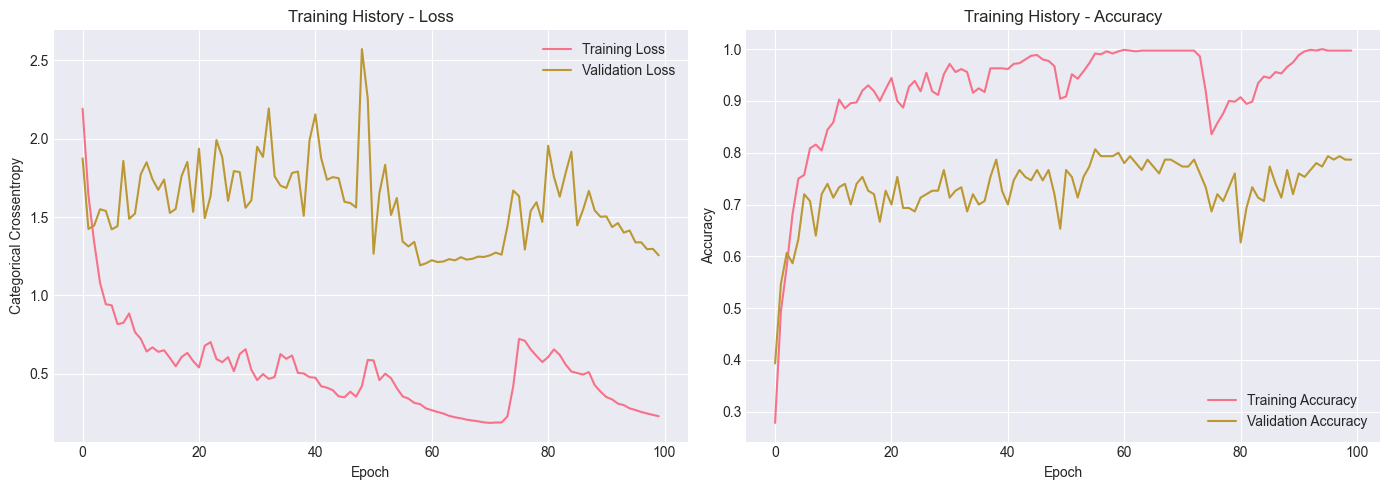

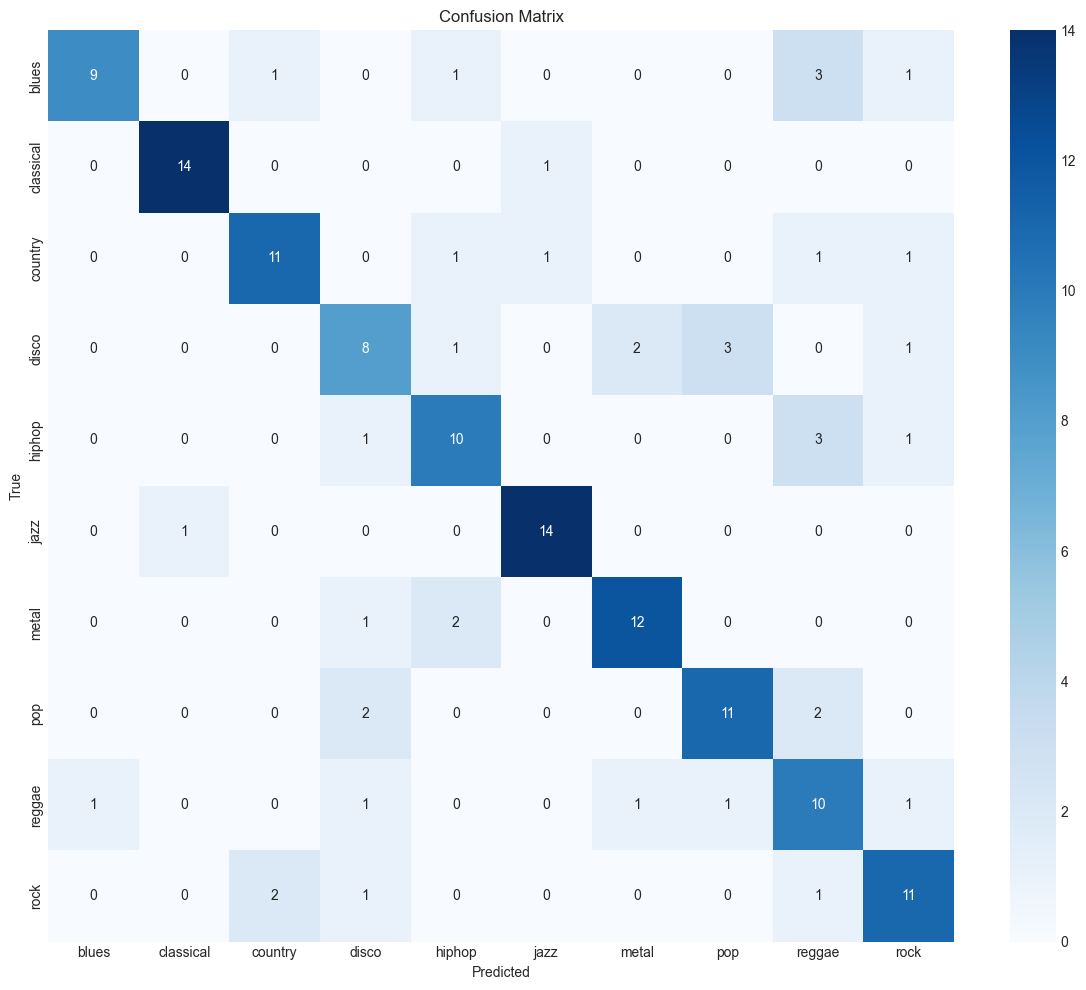


Entrenando arch_3_3_L21_ADAM1_FINAL con seed = 1...


arch_3_3_L21_ADAM1_FINAL_seed_1 Evaluation
Accuracy: 0.7533 (75.33%)

              precision    recall  f1-score   support

       blues       1.00      0.73      0.85        15
   classical       0.88      0.93      0.90        15
     country       0.73      0.73      0.73        15
       disco       0.70      0.47      0.56        15
      hiphop       0.62      0.67      0.65        15
        jazz       0.82      0.93      0.88        15
       metal       0.81      0.87      0.84        15
         pop       0.75      0.80      0.77        15
      reggae       0.61      0.73      0.67        15
        rock       0.67      0.67      0.67        15

    accuracy                           0.75       150
   macro avg       0.76      0.75      0.75       150
weighted avg       0.76      0.75      0.75       150



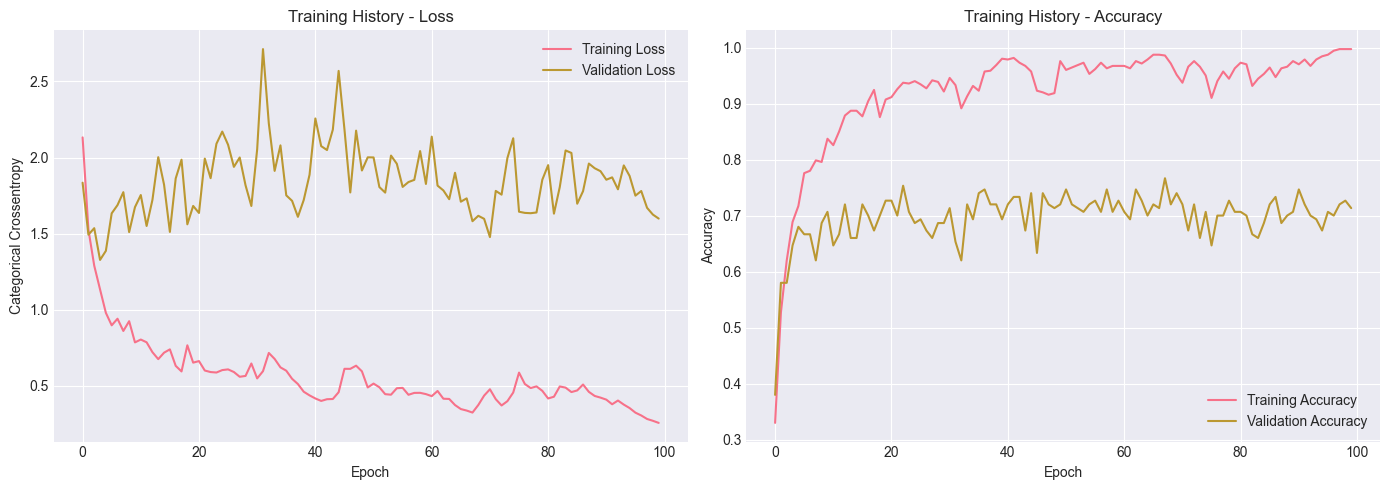

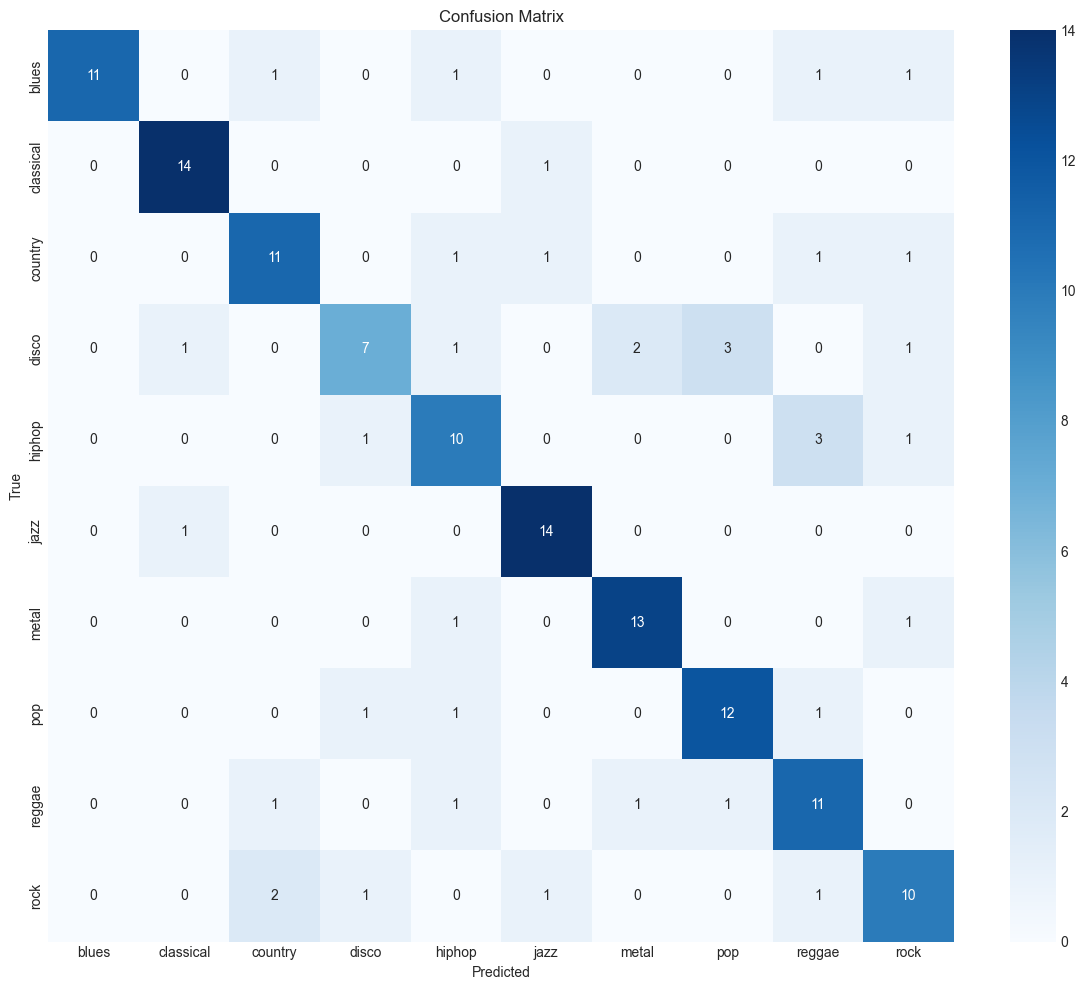


Entrenando arch_3_3_L21_ADAM1_FINAL con seed = 2...


arch_3_3_L21_ADAM1_FINAL_seed_2 Evaluation
Accuracy: 0.7267 (72.67%)

              precision    recall  f1-score   support

       blues       0.69      0.60      0.64        15
   classical       0.93      0.87      0.90        15
     country       0.60      0.60      0.60        15
       disco       0.67      0.53      0.59        15
      hiphop       0.86      0.80      0.83        15
        jazz       0.67      0.80      0.73        15
       metal       0.88      0.93      0.90        15
         pop       0.70      0.93      0.80        15
      reggae       0.63      0.80      0.71        15
        rock       0.67      0.40      0.50        15

    accuracy                           0.73       150
   macro avg       0.73      0.73      0.72       150
weighted avg       0.73      0.73      0.72       150



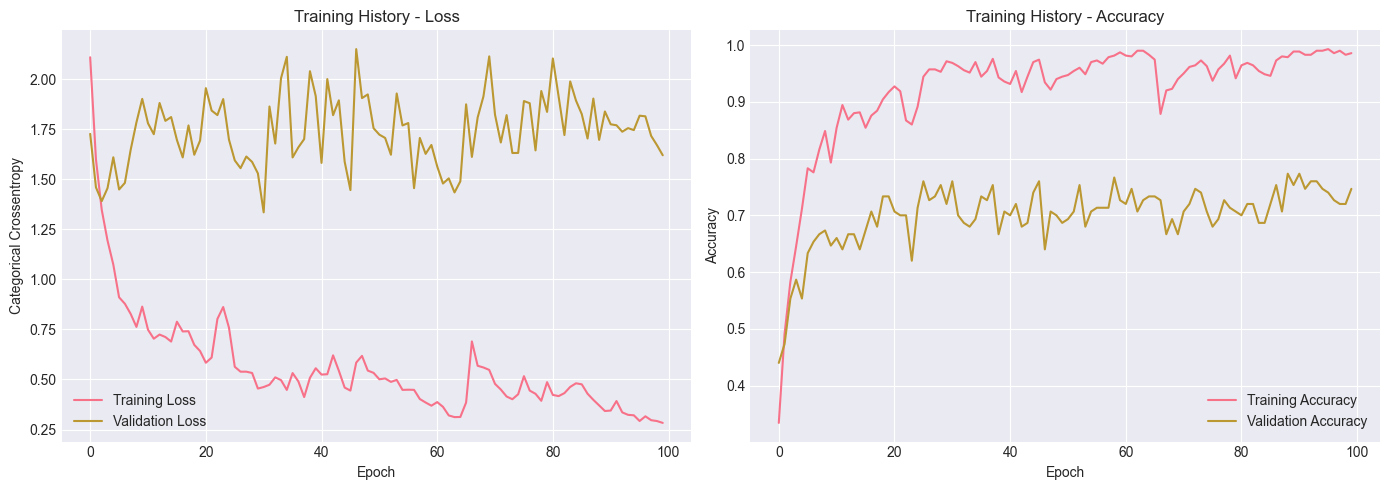

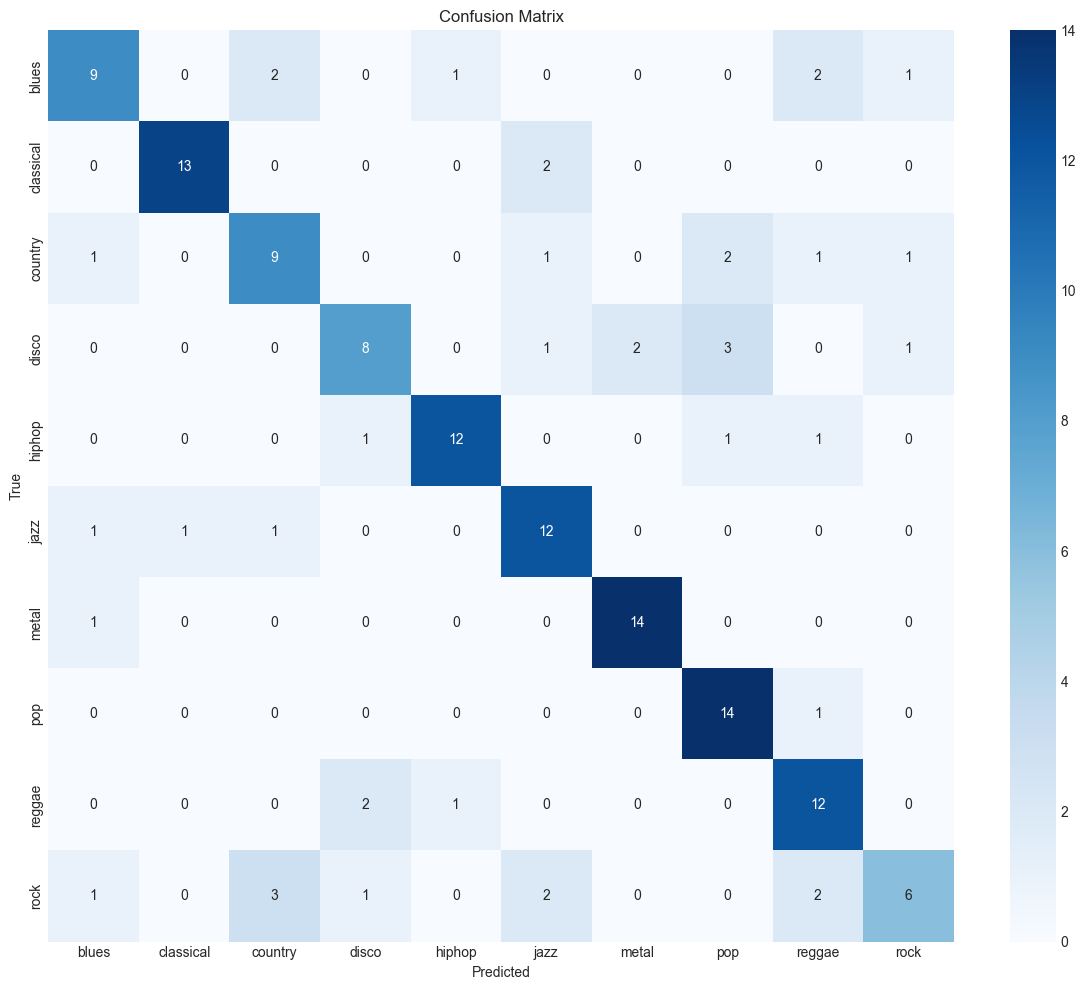


Entrenando arch_3_3_L21_ADAM1_FINAL con seed = 3...


arch_3_3_L21_ADAM1_FINAL_seed_3 Evaluation
Accuracy: 0.7533 (75.33%)

              precision    recall  f1-score   support

       blues       0.92      0.80      0.86        15
   classical       0.93      0.87      0.90        15
     country       0.77      0.67      0.71        15
       disco       0.67      0.53      0.59        15
      hiphop       0.75      0.60      0.67        15
        jazz       0.70      0.93      0.80        15
       metal       0.91      0.67      0.77        15
         pop       0.74      0.93      0.82        15
      reggae       0.63      0.80      0.71        15
        rock       0.65      0.73      0.69        15

    accuracy                           0.75       150
   macro avg       0.77      0.75      0.75       150
weighted avg       0.77      0.75      0.75       150



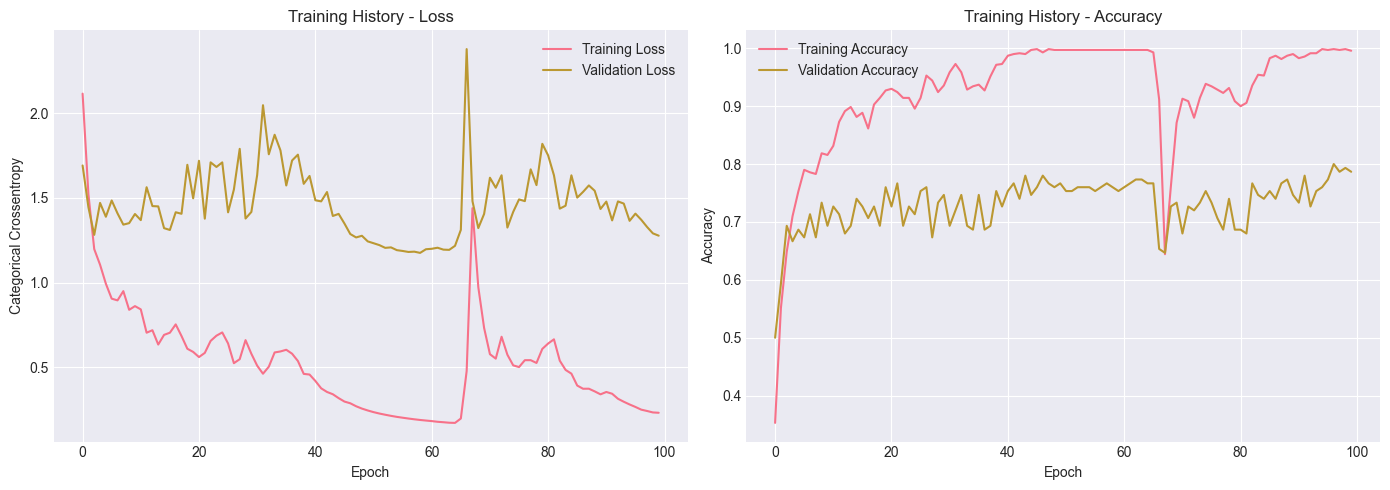

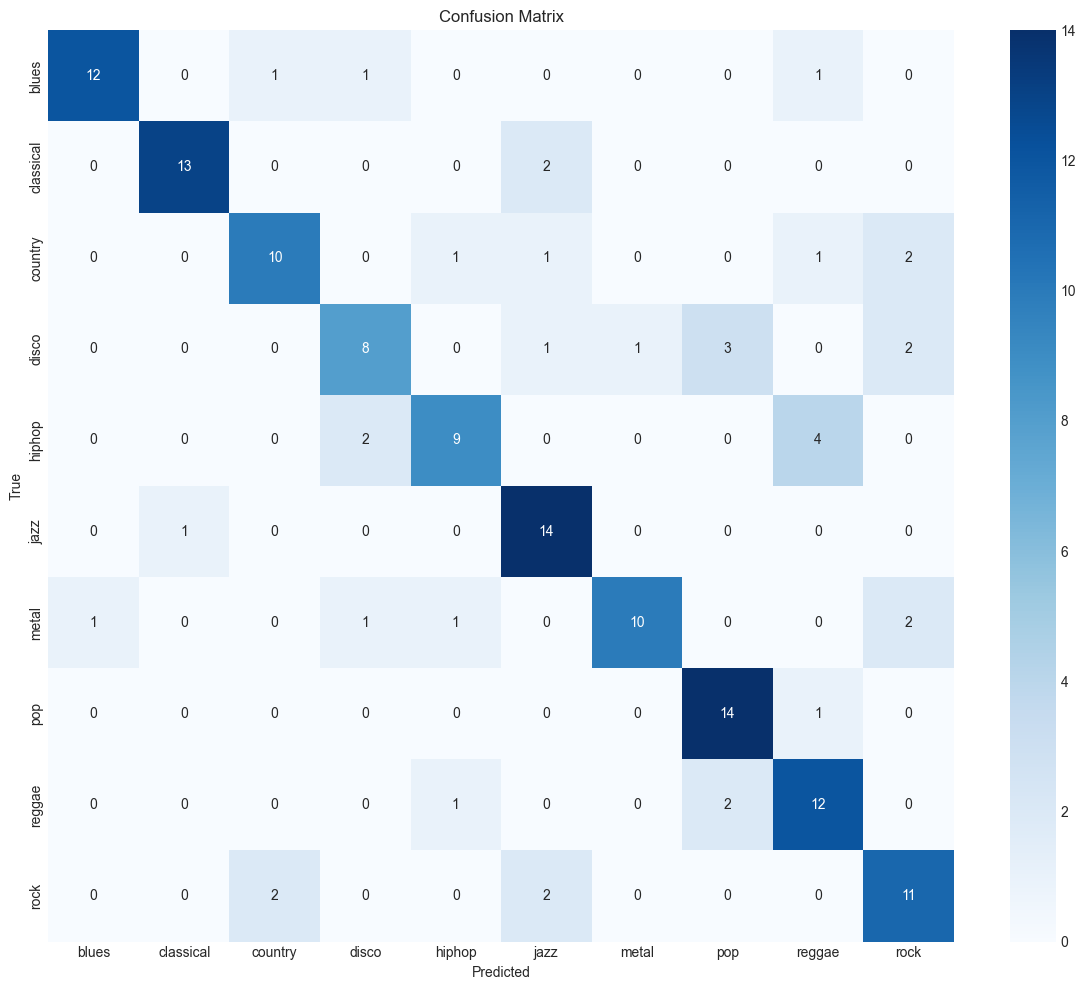

In [46]:
# Definir la arquitectura del modelo arch_3_3_L21_ADAM1_FINAL
def create_model_arch_3_3_L21_ADAM1_FINAL(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001))
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=0.01, beta_1=0.9, beta_2=0.999),
        metrics=['accuracy']
    )

    return model

seeds = [0, 1, 2, 3]
results_arch_3_3_L21_ADAM1_FINAL = []
accuracies_arch_3_3_L21_ADAM1_FINAL = []

for seed in seeds:
    keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    model = create_model_arch_3_3_L21_ADAM1_FINAL(input_dim, num_classes)

    print(f"\nEntrenando arch_3_3_L21_ADAM1_FINAL con seed = {seed}...\n")
    history = model.fit(
        X_train_scaled, y_train_cat,
        validation_data=(X_val_scaled, y_val_cat),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    result = evaluate_classifier(model, X_test_scaled, y_test, class_names, model_name=f"arch_3_3_L21_ADAM1_FINAL_seed_{seed}")
    results_arch_3_3_L21_ADAM1_FINAL.append(result)
    accuracies_arch_3_3_L21_ADAM1_FINAL.append(result['Accuracy'])

    # Graficar entrenamiento
    plot_training_history_classification(history)

    # Matriz de confusión
    plot_confusion_matrix_custom(y_test, result['Predictions'], class_names)


In [47]:
# Comparación de arch_3_3_L21_ADAM1_FINAL con modelos baseline
comparison_arch_3_3_L21_ADAM1_FINAL_df = pd.DataFrame({
    'Modelo': [
        'Logistic Regression', 
        'Random Forest', 
        'Arch_3.3_L21_ADAM1_FINAL (seed=0)', 
        'Arch_3.3_L21_ADAM1_FINAL (seed=1)', 
        'Arch_3.3_L21_ADAM1_FINAL (seed=2)', 
        'Arch_3.3_L21_ADAM1_FINAL (seed=3)',
    ],
    'Accuracy': [
        lr_acc, 
        rf_acc, 
        accuracies_arch_3_3_L21_ADAM1_FINAL[0], 
        accuracies_arch_3_3_L21_ADAM1_FINAL[1], 
        accuracies_arch_3_3_L21_ADAM1_FINAL[2], 
        accuracies_arch_3_3_L21_ADAM1_FINAL[3],
    ]
})

comparison_arch_3_3_L21_ADAM1_FINAL_df

,Modelo,Accuracy
0,Logistic Regression,0.740000
1,Random Forest,0.760000
2,Arch_3.3_L21_ADAM1_FINAL (seed=0),0.733333
3,Arch_3.3_L21_ADAM1_FINAL (seed=1),0.753333
4,Arch_3.3_L21_ADAM1_FINAL (seed=2),0.726667
5,Arch_3.3_L21_ADAM1_FINAL (seed=3),0.753333


En cuanto al **output**, se observa que la gráfica final de **accuracy** mejora claramente y la de **training loss** empeora un poco, con respecto al modelo inicial. En general. se refleja un aprendizaje más efectivo y un mejor desempeño general del modelo en los datos de prueba.

La forma de estas curvas presenta saltos más bruscos durante el entrenamiento, lo cual se debe a que, para optimizar el modelo, se incrementó el **learning rate**. Este valor más alto permite actualizaciones de pesos más rápidas, acelerando el aprendizaje, aunque también introduce cierta inestabilidad momentánea en las métricas durante las primeras épocas.

### **Análisis de las Features más importantes para nuestro modelo final**

Para evaluar la relevancia de las distintas características en nuestro modelo de clasificación final, se ha utilizado la técnica de **Permutation Importance**. Esta metodología permite medir cómo afecta cada feature al rendimiento del modelo, cuantificado mediante la métrica de **accuracy**, al permutar sus valores y observar el cambio en el desempeño. Con ello, podemos identificar cuáles son las **features más influyentes** para la predicción y cuáles tienen un impacto menor, lo que ayuda tanto a interpretar el modelo como a guiar posibles mejoras o simplificaciones del mismo.



Entrenando arch_3_3_L21_ADAM1_FINAL para poder analizar las features

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━

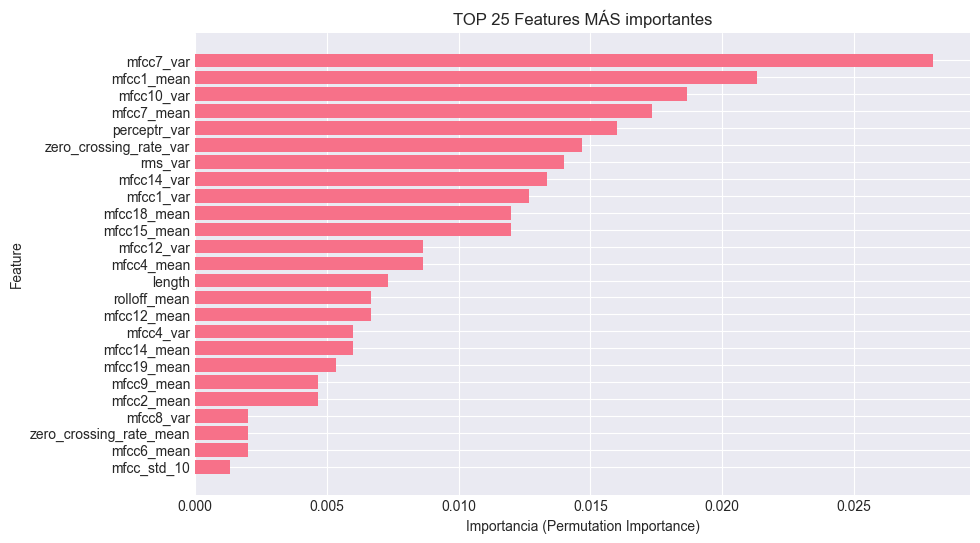

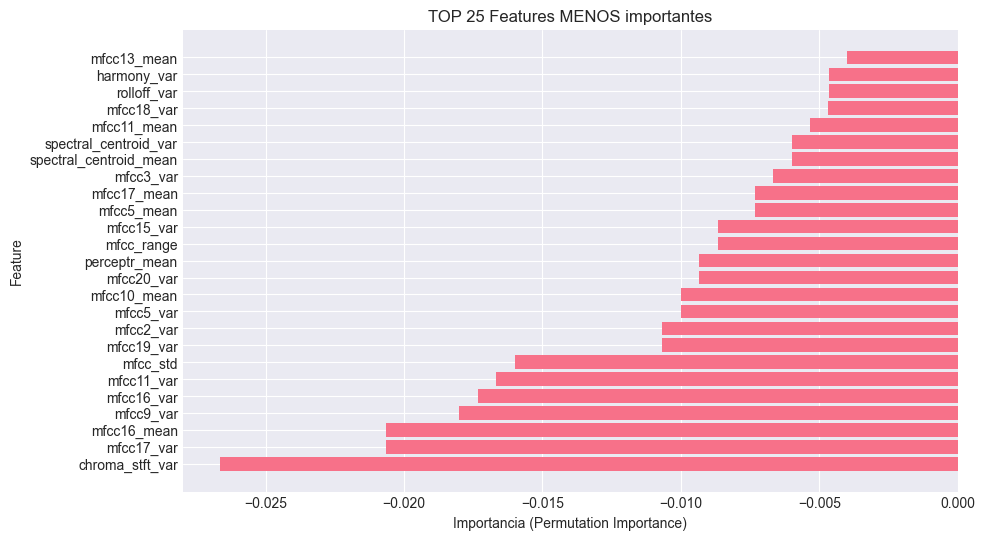

In [ ]:
from sklearn.base import BaseEstimator
from sklearn.inspection import permutation_importance

# Creamos y entrenamos el modelo final
modelo_final = create_model_arch_3_3_L21_ADAM1(input_dim, num_classes)
print(f"\nEntrenando arch_3_3_L21_ADAM1_FINAL para poder analizar las features\n")
history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=100,
    batch_size=32,
    verbose=0
)
print(f"\nEntrenamiento terminado\n")

# Recuperamos el nombre de las columnas en x_test_scaled
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Wrapper para clasificación multiclase
class KerasWrapper(BaseEstimator):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        probs = self.model.predict(X)
        return probs.argmax(axis=1)

# Crear wrapper
wrapped_model = KerasWrapper(modelo_final)

# Permutation Importance con accuracy
result = permutation_importance(
    wrapped_model,
    X_test_scaled,
    y_test,
    scoring='accuracy',
    n_repeats=10,
    random_state=42
)

# DataFrame ordenado
feature_importances = pd.DataFrame({
    'feature': X_test_scaled.columns if hasattr(X_test_scaled, 'columns') else [f'X{i}' for i in range(X_test_scaled.shape[1])],
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

# Top 25 más importantes
top25_best = feature_importances.head(25)

# Top 25 menos importantes
top25_worst = feature_importances.tail(25)

# Mostrar en consola
print("Top 25 Features MÁS importantes:")
print(top25_best)
print("\nTop 25 Features MENOS importantes:")
print(top25_worst)

# ============================
#      GRÁFICA TOP 25 BEST
# ============================
plt.figure(figsize=(10,6))
plt.barh(top25_best['feature'], top25_best['importance'])
plt.xlabel("Importancia (Permutation Importance)")
plt.ylabel("Feature")
plt.title("TOP 25 Features MÁS importantes")
plt.gca().invert_yaxis()
plt.show()

# ============================
#      GRÁFICA TOP 25 WORST
# ============================
plt.figure(figsize=(10,6))
plt.barh(top25_worst['feature'], top25_worst['importance'])
plt.xlabel("Importancia (Permutation Importance)")
plt.ylabel("Feature")
plt.title("TOP 25 Features MENOS importantes")
plt.gca().invert_yaxis()
plt.show()



El análisis de importancia de features revela cuáles características son más relevantes para la clasificación del modelo final. En el **Top 25 de features más importantes**, predominan principalmente los coeficientes MFCC, tanto en media como en varianza (`mfcc7_var`, `mfcc1_mean`, `mfcc10_var`, `mfcc7_mean`), lo que indica que el timbre y las variaciones en la señal sonora son factores clave para diferenciar entre las 10 clases. También aparecen algunas métricas relacionadas con la percepción y la energía de la señal (`perceptr_var`, `rms_var`) y características rítmicas como `zero_crossing_rate_var`, lo que sugiere que la dinámica y el contenido temporal de la música contribuyen significativamente a las predicciones. La presencia de `length` entre las más importantes indica que la duración de la pista también aporta información útil, aunque en menor medida.

Por otro lado, en el **Top 25 de features menos importantes** predominan características espectrales (`spectral_centroid_mean`, `spectral_centroid_var`, `rolloff_var`) y algunos MFCC menos representativos (`mfcc16_mean`, `mfcc17_var`). Algunos valores incluso son negativos, lo que significa que permutar esas features puede mejorar ligeramente la predicción, indicando que estas variables aportan poca información relevante o incluso ruido al modelo. Esto evidencia que no todas las características extraídas de la señal musical son igualmente útiles, y que el modelo se apoya principalmente en patrones tímbricos y variaciones de los MFCC para realizar la clasificación.

En conjunto, estos resultados permiten concluir que la selección de features basada en importancia podría guiar futuras mejoras del modelo, priorizando aquellas variables que realmente aportan información discriminativa y descartando o transformando aquellas que aportan poco o pueden introducir ruido.

---
# Parte 8: Conclusiones


<span style="color:red">COMENTA LOS RESULTADOS FINALES OBTENIDOS Y QUÉ SE PUEDE MEJORAR.</span >

El modelo final elegido, **`arch_3_3_L21_ADAM1`**, ha demostrado ser efectivo para clasificar las pistas musicales en las 10 categorías establecidas. Gracias a la combinación de la regularización L2 y el optimizador Adam, el modelo logra controlar los pesos y evitar el sobreajuste, lo que se traduce en una mayor capacidad de generalización y mejores resultados en los datos de prueba.

Al observar las gráficas de **accuracy** y **training loss**, se nota que la gráfica final de **accuracy** mejora claramente y la de **training loss** empeora un poco, con respecto al modelo inicial. En general, el aprendizaje es más rápido y el desempeño general ha aumentado, aunque las curvas presentan saltos más bruscos debido a que se utilizó un **learning rate** más alto, que permite actualizar los pesos más rápidamente pero introduce cierta inestabilidad momentánea durante el entrenamiento.

El análisis de importancia de features indica que el modelo se centra principalmente en características tímbricas y perceptuales complejas, como los coeficientes MFCC y medidas de percepción, mientras que las características espectrales y algunas rítmicas tienen menos influencia. Esto sugiere que el timbre y la textura de las pistas son factores clave para diferenciar entre las categorías musicales.

En conjunto, estas conclusiones muestran que el modelo no solo ha mejorado en precisión y estabilidad, sino que también aprende a identificar los patrones más relevantes en los datos. Además, el análisis de features puede ayudar a futuras optimizaciones, permitiendo centrarse en las variables que realmente aportan información útil para la clasificación.

Aunque el modelo final funciona bien, todavía se podría mejorar explorando técnicas adicionales como ajustar más finamente el learning rate, probar otras combinaciones de regularizaciones L1 y L2, o implementar arquitecturas más profundas o con capas recurrentes para capturar mejor dependencias temporales en la música. También sería útil reducir o seleccionar de forma más precisa las features menos relevantes, lo que podría simplificar el modelo y mejorar su capacidad de generalización sin perder precisión.


---
# Checklist Final

Antes de la entrega, asegúrate de que:

- [ ] Todas las celdas de código se ejecutan sin errores
- [ ] Las visualizaciones son coherentes
- [ ] Los resultados están interpretados y discutidos
- [ ] Las celdas markdown explican tu razonamiento
- [ ] El código es legible y las partes importantes están comentadas
- [ ] Las semillas aleatorias están fijadas para reproducibilidad

---
*Práctica 2: Clasificación de géneros musicales - Asignaturas de Redes Neuronales*  
*Máster en Deep Learning - Octubre 2025*